# Proyek Analisis Data: Olist Brazilian E-Commerce Public Dataset
- **Nama:** Syifa Azzahirah
- **Email:** azzahirahsyifa1@gmail.com

**Dataset Source:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce

## 1. Menentukan Pertanyaan Bisnis (EDA Dasar)

1. Produk dan Penjualan:
- P1: Apa kategori produk terpopuler berdasarkan jumlah pesanan?
- P2: Bagaimana pola pembelian harian, mingguan, atau bulanan? Apakah ada waktu tertentu dengan volume penjualan yang tinggi?
- P3: Apa produk yang memiliki total pendapatan tertinggi?
2. Pelanggan:
- P4: Dari daerah mana pelanggan terbanyak berasal?
- P5: Apa rasio pelanggan baru dan pelanggan yang sudah pernah membeli sebelumnya?
3. Pembayaran:
- P6: Metode pembayaran apa yang paling sering digunakan?
- P7: Apakah terdapat hubungan antara jenis pembayaran dan waktu pengiriman?
4. Ulasan dan Kepuasan Pelanggan:
- P8: Bagaimana distribusi rating ulasan pelanggan? Apakah mayoritas ulasan bernada positif atau negatif?
- P9: Apakah ada perbedaan waktu pengiriman antara pesanan yang diberi ulasan positif dan negatif?
5. Pengiriman:
- P10: Berapa rata-rata waktu pengiriman berdasarkan kategori produk?
- P11: Apakah terdapat keterlambatan pengiriman yang sering terjadi pada kategori produk tertentu?
- P12: Berapa persentase pengiriman yang dilakukan tepat waktu dibandingkan dengan yang terlambat?



---



## 2. Import Semua Packages/Library yang Digunakan

In [ ]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Configure plot style
sns.set(style="whitegrid")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive




---



## 3. Data Wrangling

### 3. 1. Gathering Data

####3. 1. 1. Orders Dataset

In [ ]:
orders_df = pd.read_csv('/content/drive/My Drive/orders_dataset.csv')
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


####3. 1. 2. Products Dataset

In [ ]:
products_df = pd.read_csv('/content/drive/My Drive/products_dataset.csv')
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


####3. 1. 3. Order Items Dataset

In [ ]:
order_items_df = pd.read_csv('/content/drive/My Drive/order_items_dataset.csv')
order_items_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


####3. 1. 4. Order Payments Dataset

In [ ]:
order_payments_df = pd.read_csv('/content/drive/My Drive/order_payments_dataset.csv')
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


####3. 1. 5. Order Reviews Dataset

In [ ]:
order_reviews_df = pd.read_csv('/content/drive/My Drive/order_reviews_dataset.csv')
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


####3. 1. 6. Customers Dataset

In [ ]:
customers_df = pd.read_csv('/content/drive/My Drive/customers_dataset.csv')
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


####3. 1. 7. Geolocation Dataset

In [ ]:
geolocation_df = pd.read_csv('/content/drive/My Drive/geolocation_dataset.csv')
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


####3. 1. 8. Product Category Name Translation Dataset (in English)

In [ ]:
product_category_name_translations_df = pd.read_csv('/content/drive/My Drive/product_category_name_translation.csv')
product_category_name_translations_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


####3. 1. 9. Sellers Dataset

In [ ]:
sellers_df = pd.read_csv('/content/drive/My Drive/sellers_dataset.csv')
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:**

Telah dilakukan proses Data Gathering pada Olist E-Commerce Dataset

###3. 2. Assessing Data

####3. 2. 1. Orders Dataset

In [ ]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


Insight:

**Orders Dataset**
- Kolom *order_approved_at* memiliki 160 nilai yang hilang.
- Kolom *order_delivered_carrier_date* memiliki 1783 nilai yang hilang
- Kolom *order_delivered_customer_date* memiliki 2965 nilai yang hilang
- Tipe data di kolom *order_purchase_timestamp*, *order_approved_at*, *order_delivered_carrier_date*, *order_delivered_customer_date*, dan *order_estimated_delivery_date* tidak sesuai (wrong data type).

####3. 2. 2. Products Dataset

In [ ]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
customers_df.duplicated().sum()

np.int64(0)

In [ ]:
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


Insight:

**Products Dataset**
- Hanya kolom *product_id* yang tidak memiliki nilai yang hilang, kolom lainnya mengandung missing values.

####3. 2. 3. Order Items Dataset

In [ ]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
order_items_df.duplicated().sum()

np.int64(0)

In [ ]:
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


Insight:

**Order Items Dataset**
- Tidak ada catatan atau missing values.

####3. 2. 4. Order Payments Dataset

In [ ]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [ ]:
order_payments_df.duplicated().sum()

np.int64(0)

In [ ]:
order_payments_df.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


Insight:

 **Order Payments Dataset**
- Tidak ada catatan atau missing values.

####3. 2. 5. Order Reviews Dataset

In [ ]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [ ]:
order_reviews_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_comment_title,87656
review_comment_message,58247
review_creation_date,0
review_answer_timestamp,0


In [ ]:
order_reviews_df.duplicated().sum()

np.int64(0)

In [ ]:
order_reviews_df.describe()

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


Insight:

**Order Reviews Dataset**
- Kolom *review_comment_title* memiliki 87,656 nilai yang hilang.
- Kolom *review_comment_message* memiliki 58,247 nilai yang hilang.
- Tipe data di kolom *review_creation_date* dan *review_answer_timestamp* tidak sesuai (wrong data type).

####3. 2. 6. Customers Dataset

In [ ]:
customers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
customers_df.duplicated().sum()

np.int64(0)

In [ ]:
customers_df.describe()

,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


Insight:

**Customers Dataset**
- Tidak ada catatan atau missing values.

####3. 2. 7. Geolocation Dataset

In [ ]:
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [ ]:
geolocation_df.duplicated().sum()

np.int64(261831)

In [ ]:
geolocation_df.describe()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


Insight:

**Geolocation Dataset**
- Terdapat 261,831 record yang duplikat.

####3. 2. 8. Product Category Name Translation Dataset (in English)

In [ ]:
product_category_name_translations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [ ]:
product_category_name_translations_df.duplicated().sum()

np.int64(0)

In [ ]:
product_category_name_translations_df.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


Insight:

**Product Category Name Translation Dataset (in English)**
- Tidak ada catatan atau missing values.

####3. 2. 9. Sellers Dataset

In [ ]:
sellers_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [ ]:
sellers_df.duplicated().sum()

np.int64(0)

In [ ]:
sellers_df.describe()

,seller_zip_code_prefix
count,3095.000000
mean,32291.059451
std,32713.453830
min,1001.000000
25%,7093.500000
50%,14940.000000
75%,64552.500000
max,99730.000000


Insight:

 **Sellers Dataset**
- Tidak ada catatan atau missing values.

###3. 3. Cleaning Data

####3. 3. 1. Orders Dataset

In [ ]:
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
orders_df.dropna(subset=["order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date"], inplace=True)

In [ ]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       96461 non-null  object
 1   customer_id                    96461 non-null  object
 2   order_status                   96461 non-null  object
 3   order_purchase_timestamp       96461 non-null  object
 4   order_approved_at              96461 non-null  object
 5   order_delivered_carrier_date   96461 non-null  object
 6   order_delivered_customer_date  96461 non-null  object
 7   order_estimated_delivery_date  96461 non-null  object
dtypes: object(8)
memory usage: 6.6+ MB


#####Correct the columns with the right datatype

In [ ]:
datetime_columns = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

In [ ]:
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96461 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96461 non-null  object        
 1   customer_id                    96461 non-null  object        
 2   order_status                   96461 non-null  object        
 3   order_purchase_timestamp       96461 non-null  datetime64[ns]
 4   order_approved_at              96461 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96461 non-null  datetime64[ns]
 6   order_delivered_customer_date  96461 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96461 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


####3. 3. 2. Products Dataset

In [ ]:
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [ ]:
products_df = products_df[['product_id', 'product_category_name']]
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   product_id             32951 non-null  object
 1   product_category_name  32341 non-null  object
dtypes: object(2)
memory usage: 515.0+ KB


In [ ]:
products_df.isna().sum()

,0
product_id,0
product_category_name,610


In [ ]:
products_df["product_category_name"].fillna("outros", inplace=True)
products_df.isna().sum()

<ipython-input-48-9d76475b9e6a>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  products_df["product_category_name"].fillna("outros", inplace=True)


,0
product_id,0
product_category_name,0


####3. 3. 3. Order Reviews Dataset

In [ ]:
order_reviews_df.drop(columns=["review_comment_title", "review_comment_message"], inplace=True)

In [ ]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_creation_date     99224 non-null  object
 4   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [ ]:
order_reviews_df.isna().sum()

,0
review_id,0
order_id,0
review_score,0
review_creation_date,0
review_answer_timestamp,0


In [ ]:
datetime_columns = ['review_creation_date', 'review_answer_timestamp']

for column in datetime_columns:
    order_reviews_df[column] = pd.to_datetime(order_reviews_df[column])

In [ ]:
order_reviews_df.dtypes

,0
review_id,object
order_id,object
review_score,int64
review_creation_date,datetime64[ns]
review_answer_timestamp,datetime64[ns]


**Insight:**

Proses pembersihan data telah dilakukan meliputi langkah-langkah berikut:
1. Menghapus Data Duplikat
2. Menghapus Baris dengan Nilai Kosong
3. Memperbaiki Tipe Data
4. Menghapus Kolom yang Tidak Digunakan
5. Mengisi Baris dengan Nilai Kosong



---



##4. Exploratory Data Analysis (EDA)

###4. 1. Explore Orders Dataset

####4. 1. 1. Orders Based On Years

In [ ]:
orders_df['purchase_year'] = pd.DatetimeIndex(orders_df['order_purchase_timestamp']).year

In [ ]:
orders_per_year = orders_df.groupby('purchase_year').size().reset_index(name='total_orders').sort_values('purchase_year')

orders_per_year

,purchase_year,total_orders
0,2016,272
1,2017,43411
2,2018,52778


####4. 1. 2. Orders Based On Months

In [ ]:
orders_df['purchase_month'] = orders_df['order_purchase_timestamp'].dt.strftime('%B')

In [ ]:
orders_per_month = (
    orders_df.groupby('purchase_month')
    .size()
    .reset_index(name='total_orders')
)

month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

orders_per_month['purchase_month'] = pd.Categorical(orders_per_month['purchase_month'], categories=month_order, ordered=True)
orders_per_month = orders_per_month.sort_values('purchase_month').reset_index(drop=True)

orders_per_month

,purchase_month,total_orders
0,January,7817
1,February,8197
2,March,9549
3,April,9101
4,May,10294
5,June,9231
6,July,10028
7,August,10544
8,September,4150
9,October,4748


####4. 1. 3. Order Based On State

In [ ]:
merged_order_customer_df = pd.merge(
    orders_df,
    customers_df,
    on='customer_id',
    how='left'
)

In [ ]:
orders_by_state = (
    merged_order_customer_df.groupby('customer_state')
    .size()
    .reset_index(name='total_orders')
    .rename(columns={'customer_state': 'state'})
)

orders_by_state

,state,total_orders
0,AC,80
1,AL,397
2,AM,145
3,AP,67
4,BA,3256
5,CE,1278
6,DF,2080
7,ES,1995
8,GO,1957
9,MA,716


###4. 2. Explore Products Dataset

####Combine the products dataset with translated product category name

In [ ]:
products_df

,product_id,product_category_name
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria
1,3aa071139cb16b67ca9e5dea641aaa2f,artes
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer
3,cef67bcfe19066a932b7673e239eb23d,bebes
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas
...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios


In [ ]:
product_category_name_translations_df

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [ ]:
product_category_merged_df = products_df.merge(
    product_category_name_translations_df,
    how='left',
    left_on='product_category_name',
    right_on='product_category_name'
)

product_category_merged_df

,product_id,product_category_name,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares
...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,furniture_decor
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,construction_tools_lights
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,bed_bath_table
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,computers_accessories


In [ ]:
product_category_merged_df.drop(columns='product_category_name', inplace=True)

product_category_merged_df

,product_id,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,art
2,96bd76ec8810374ed1b65e291975717f,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,baby
4,9dc1a7de274444849c219cff195d0b71,housewares
...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,furniture_decor
32947,bf4538d88321d0fd4412a93c974510e6,construction_tools_lights
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,bed_bath_table
32949,83808703fc0706a22e264b9d75f04a2e,computers_accessories


###4. 3. Explore Order Items Dataset

In [ ]:
order_items_df.groupby(by='order_item_id').agg({
    'order_id': 'nunique'
})

,order_id
order_item_id,
1,98666
2,9803
3,2287
4,965
5,460
6,256
7,58
8,36
9,28


In [ ]:
merged_order_items_products_df = order_items_df.merge(
    product_category_merged_df,
    how='left',
    on='product_id'
)

merged_order_items_products_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,garden_tools
...,...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41,housewares
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53,computers_accessories
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95,sports_leisure
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72,computers_accessories


In [ ]:
order_product_category_df = merged_order_items_products_df[['order_id', 'product_category_name_english']].groupby(by='product_category_name_english').agg({
    'order_id': 'count'
}).reset_index()

order_product_category_df.rename(columns={'order_id': 'total_order'}, inplace=True)

order_product_category_df

,product_category_name_english,total_order
0,agro_industry_and_commerce,212
1,air_conditioning,297
2,art,209
3,arts_and_craftmanship,24
4,audio,364
...,...,...
66,stationery,2517
67,tablets_printing_image,83
68,telephony,4545
69,toys,4117


###4. 4. Explore Order Reviews Dataset

In [ ]:
order_reviews_df

,review_id,order_id,review_score,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,2018-03-01,2018-03-02 10:26:53
...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,2018-07-01,2018-07-02 12:59:13


In [ ]:
review_counts_df = (
    order_reviews_df.groupby('review_score')
    .size()
    .reset_index(name='total_reviews')
)

review_counts_df

,review_score,total_reviews
0,1,11424
1,2,3151
2,3,8179
3,4,19142
4,5,57328


###4. 5. Explore Customers Dataset

In [ ]:
customer_status_df = customers_df[['customer_id']].copy()
customer_status_df['status'] = customer_status_df['customer_id'].isin(orders_df['customer_id']).replace({True: 'Active', False: 'Inactive'})

customer_status_df.head()

,customer_id,status
0,06b8999e2fba1a1fbc88172c00ba8bc7,Active
1,18955e83d337fd6b2def6b18a428ac77,Active
2,4e7b3e00288586ebd08712fdd0374a03,Active
3,b2b6027bc5c5109e529d4dc6358b12c3,Active
4,4f2d8ab171c80ec8364f7c12e35b23ad,Active


In [ ]:
customer_status_df = customer_status_df.groupby(by='status').agg({
    'customer_id': 'count'
}).reset_index()

customer_status_df.rename(columns={
    'customer_id': 'total_customer'
}, inplace=True)

customer_status_df

,status,total_customer
0,Active,96461
1,Inactive,2980


**Insight:**

Analisis Data Eksploratif telah menghasilkan beberapa DataFrame yang akan dimanfaatkan dalam proses Visualisasi & Analisis Eksplanatori:

1. *orders_per_year_df*
2. *orders_per_month_df*
3. *orders_by_state*
4. *product_category_merged_df*
5. *order_product_category_df*
6. *review_counts_df*
7. *customer_status_df*



---



##5. Visualization & Explanatory Analysis

###1. Produk dan Penjualan

####P1: Apa kategori produk terpopuler berdasarkan jumlah pesanan?

In [ ]:
order_product_category_df.sort_values(by='total_order', ascending=False).head(10)

,product_category_name_english,total_order
7,bed_bath_table,11115
43,health_beauty,9670
65,sports_leisure,8641
39,furniture_decor,8334
15,computers_accessories,7827
49,housewares,6964
70,watches_gifts,5991
68,telephony,4545
42,garden_tools,4347
5,auto,4235


<ipython-input-72-f5f087e166db>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


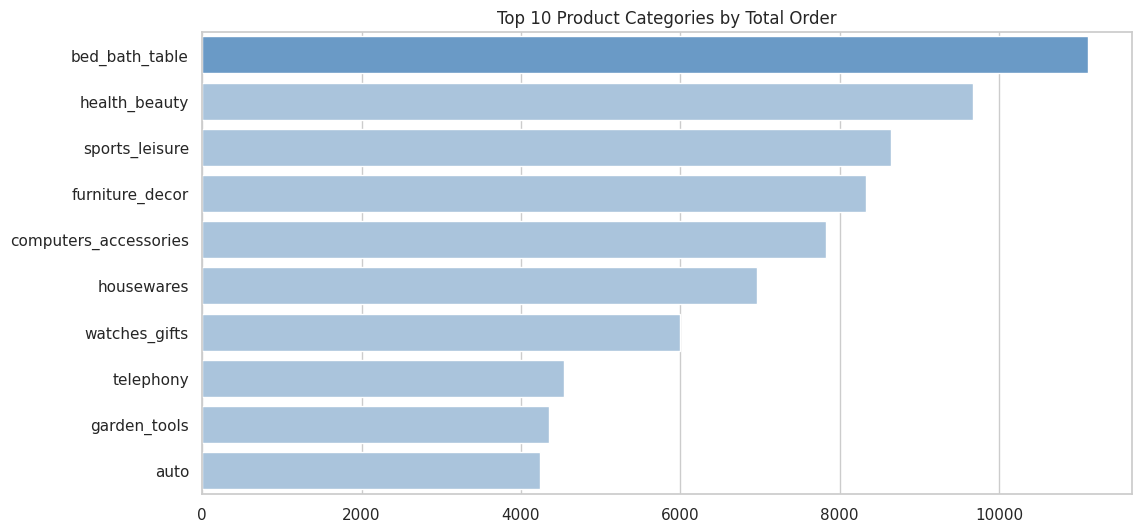

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# P1 Visualization: Top 10 Product Categories by Order Count
top_10_df = order_product_category_df.sort_values(by='total_order', ascending=False).head(10)

# Menandai kategori dengan total_order tertinggi
top_color = ['#A2C4E4' if i != top_10_df['total_order'].idxmax() else '#5B9BD5' for i in top_10_df.index]

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    y='product_category_name_english',
    x='total_order',
    data=top_10_df,
    palette=top_color
)
plt.title('Top 10 Product Categories by Total Order')
plt.xlabel('')
plt.ylabel('')
plt.show()

Insight: *bed_bath_table* memiliki jumlah pesanan tertinggi, diikuti oleh *health_beauty* dan *sports_leisure*.

####P2: Bagaimana pola pembelian harian, mingguan, atau bulanan? Apakah ada waktu tertentu dengan volume penjualan yang tinggi?

#####1. Yearly Order Trend

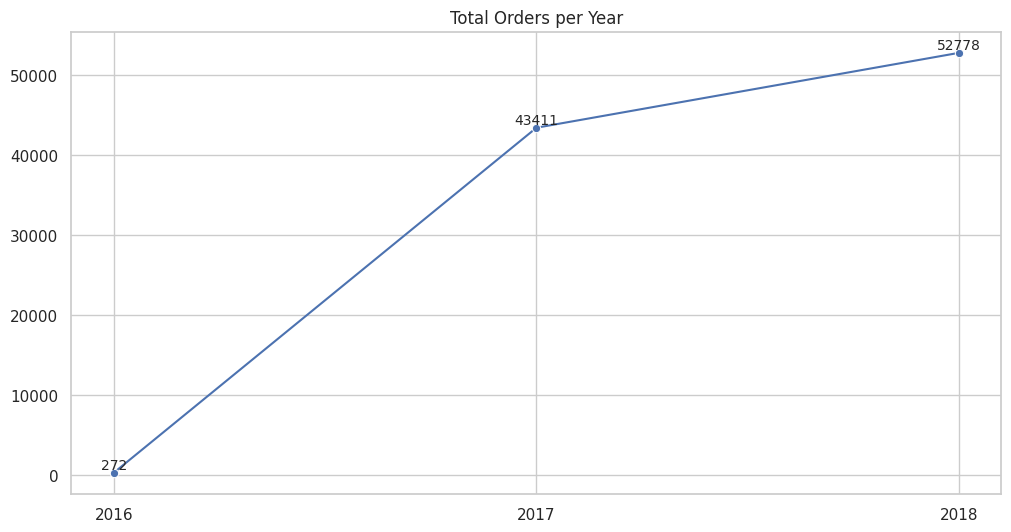

In [ ]:
# P2 Visualization: Sales Trend Over Time (Yearly)
plt.figure(figsize=(12, 6))
sns.lineplot(x='purchase_year', y='total_orders', data=orders_per_year, marker='o')
plt.title('Total Orders per Year')
plt.xlabel('')
plt.ylabel('')
plt.xticks(range(2016, 2019))  # x-axis ticks: 2016, 2017, 2018

# Tambahkan angka di setiap titik
for i in range(len(orders_per_year)):
    x = orders_per_year['purchase_year'].iloc[i]
    y = orders_per_year['total_orders'].iloc[i]
    plt.text(x, y + 10, str(y), ha='center', va='bottom', fontsize=10)

plt.show()

Insight: Pesanan menunjukkan pertumbuhan yang signifikan dari tahun ke tahun (2016 hingga 2018).

#####2. Monthly Order Trend

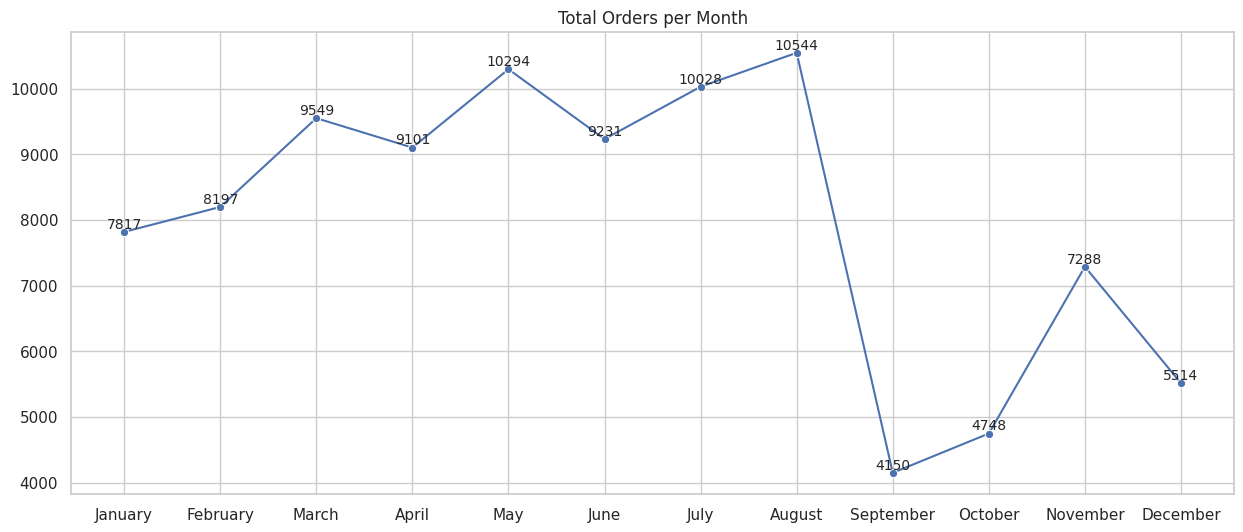

In [ ]:
# P2 Visualization: Sales Trend Over Time (Monthly)
plt.figure(figsize=(15, 6))
sns.lineplot(x='purchase_month', y='total_orders', data=orders_per_month, marker='o')
plt.title('Total Orders per Month')
plt.xlabel('')
plt.ylabel('')

# Tambahkan angka di setiap titik
for i in range(len(orders_per_month)):
    x = orders_per_month['purchase_month'].iloc[i]
    y = orders_per_month['total_orders'].iloc[i]
    plt.text(x, y + 10, str(y), ha='center', va='bottom', fontsize=10)

plt.show()

Insight: Bulan Agustus memiliki volume pesanan tertinggi, sementara bulan September menunjukkan penurunan tajam.

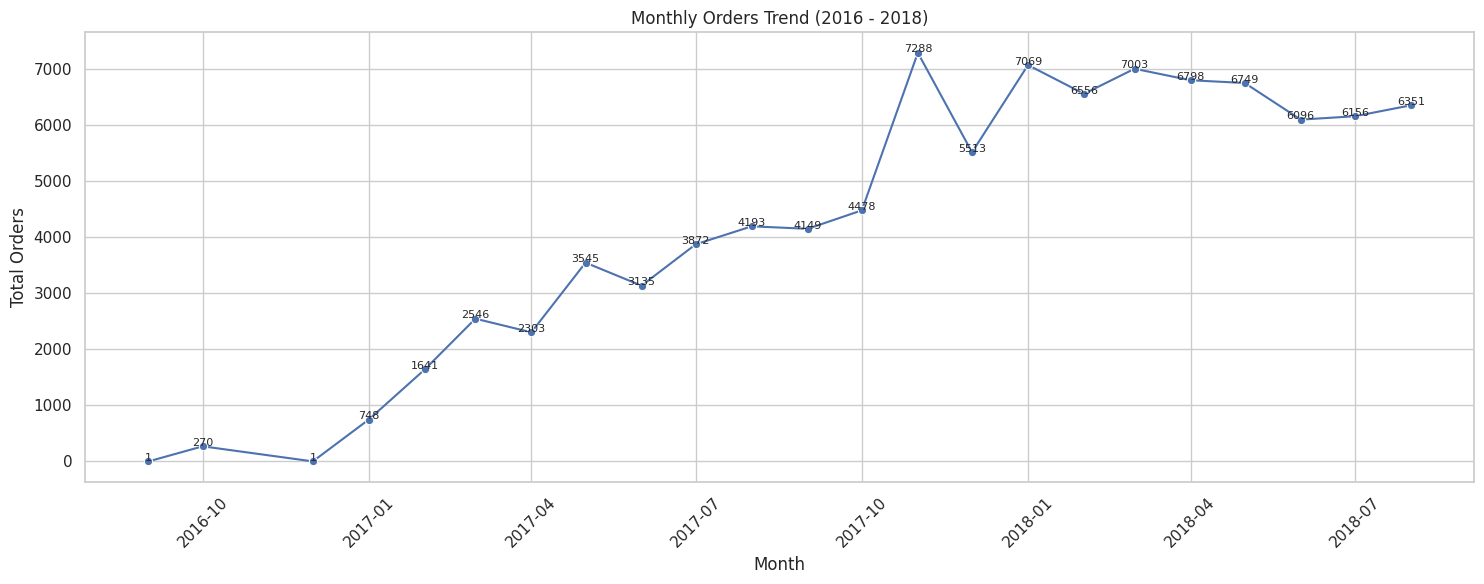

In [ ]:
# Pastikan kolom purchase_date dalam datetime
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])

# Buat kolom Year-Month (YYYY-MM)
orders_df['year_month'] = orders_df['order_purchase_timestamp'].dt.to_period('M').astype(str)

# Hitung total order per bulan
orders_per_month = orders_df.groupby('year_month')['order_id'].count().reset_index()
orders_per_month.rename(columns={'order_id': 'total_orders'}, inplace=True)

# Ubah ke datetime untuk sort dan plot
orders_per_month['year_month'] = pd.to_datetime(orders_per_month['year_month'])

# Plot
plt.figure(figsize=(15, 6))
sns.lineplot(x='year_month', y='total_orders', data=orders_per_month, marker='o')
plt.title('Monthly Orders Trend (2016 - 2018)')
plt.xlabel('Month')
plt.ylabel('Total Orders')

# Tambahkan label di setiap titik
for i in range(len(orders_per_month)):
    x = orders_per_month['year_month'].iloc[i]
    y = orders_per_month['total_orders'].iloc[i]
    plt.text(x, y + 5, str(y), ha='center', fontsize=8)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight: Bulan November 2017 memiliki volume pesanan tertinggi, sementara bulan September 2016 grafik menunjukkan volume pesanan hanya berjumlah 1.

####P3: Apa produk yang memiliki total pendapatan tertinggi?

<ipython-input-76-7f034ff1fc2d>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='total_revenue', y='product_category_name_english', data=revenue_per_category.head(10), palette=colors)
<ipython-input-76-7f034ff1fc2d>:15: UserWarning: The palette list has more values (71) than needed (10), which may not be intended.
  ax = sns.barplot(x='total_revenue', y='product_category_name_english', data=revenue_per_category.head(10), palette=colors)


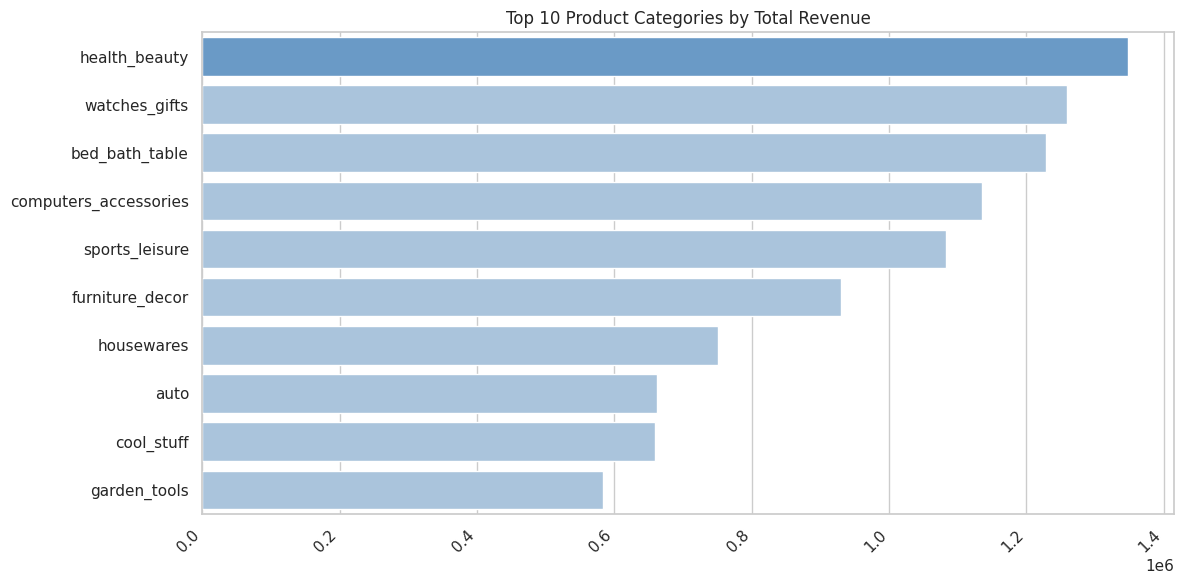

In [ ]:
# Calculate total revenue per product category
merged_df = pd.merge(order_items_df, products_df, on='product_id', how='left')
merged_df = pd.merge(merged_df, product_category_name_translations_df, on='product_category_name', how='left')
merged_df['total_revenue'] = merged_df['price'] * merged_df['order_item_id']
revenue_per_category = merged_df.groupby('product_category_name_english')['total_revenue'].sum().reset_index()
revenue_per_category = revenue_per_category.sort_values(by='total_revenue', ascending=False)


# Visualization
plt.figure(figsize=(12, 6))

# Define custom color palette
colors = ['#5B9BD5' if i == revenue_per_category['total_revenue'].idxmax() else '#A2C4E4' for i in revenue_per_category.index]

ax = sns.barplot(x='total_revenue', y='product_category_name_english', data=revenue_per_category.head(10), palette=colors)
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Product Categories by Total Revenue')
plt.xlabel('')
plt.ylabel('')
plt.tight_layout()
plt.show()

Insight: *health_beauty* menghasilkan pendapatan tertinggi.

###2. Pelanggan

####P4. Dari daerah mana pelanggan terbanyak berasal?

<ipython-input-77-0aafc58638c7>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


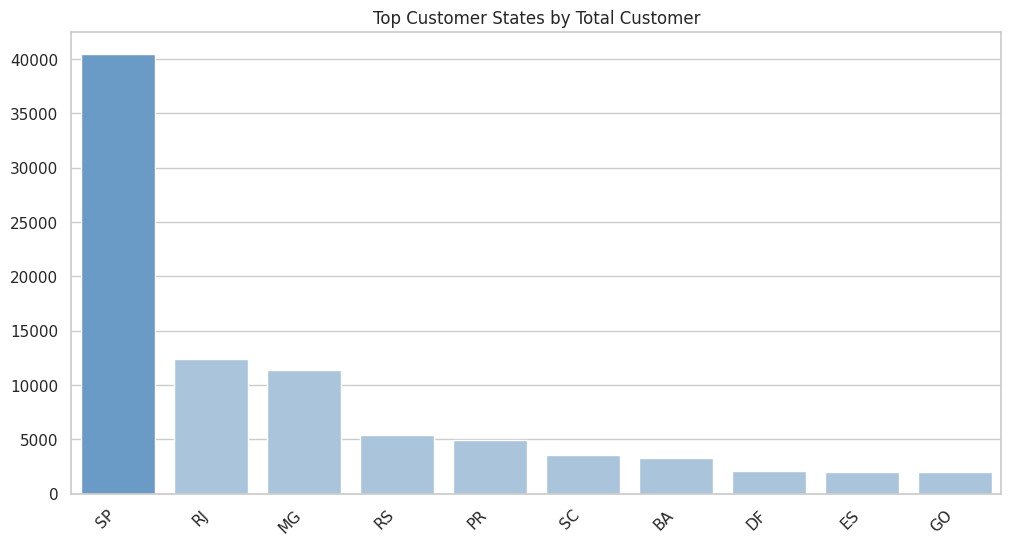

In [ ]:
# P4 Visualization: Top 10 Customer States by Customer Count
top_10_customers = merged_order_customer_df.groupby('customer_state')['customer_id'].nunique().sort_values(ascending=False).head(10).reset_index()
top_10_customers.rename(columns={'customer_id': 'total_customer'}, inplace=True)

# Menandai state dengan total_customer tertinggi
top_color = ['#A2C4E4' if i != top_10_customers['total_customer'].idxmax() else '#5B9BD5' for i in top_10_customers.index]


plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='customer_state',
    y='total_customer',
    data=top_10_customers,
    palette=top_color
)
plt.xticks(rotation=45, ha='right')
plt.title('Top Customer States by Total Customer')
plt.xlabel('')
plt.ylabel('')
plt.show()

Insight: SP (São Paulo) memiliki basis pelanggan terbesar.

####P5: Apa rasio pelanggan baru dan pelanggan yang sudah pernah membeli sebelumnya?

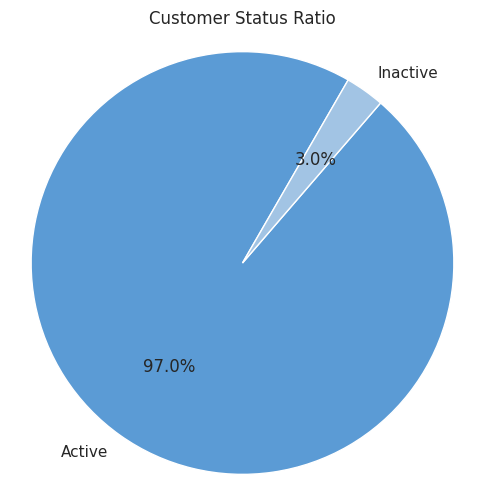

In [ ]:
# P5 Visualization: Customer Status Ratio
plt.figure(figsize=(6, 6))
plt.pie(customer_status_df['total_customer'], labels=customer_status_df['status'], autopct='%1.1f%%', startangle=60, colors=['#5B9BD5', '#A2C4E4'])
plt.title('Customer Status Ratio')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Insight: Mayoritas pelanggan (97%) adalah pelanggan aktif.

###3. Pembayaran

####P6: Metode pembayaran apa yang paling sering digunakan?

<ipython-input-79-77dfca9eb8e2>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=payment_method_counts.index, y=payment_method_counts.values, palette=colors)


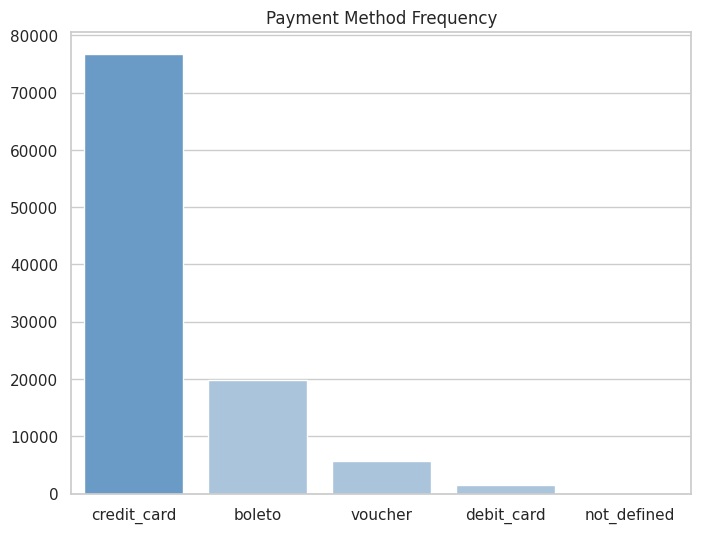

In [ ]:
# P6 Visualization: Most Frequent Payment Method
payment_method_counts = order_payments_df['payment_type'].value_counts()

# Mencari nilai maksimum dalam payment_method_counts dan set color
max_value = payment_method_counts.max()
colors = ['#A2C4E4' if count != max_value else '#5B9BD5' for count in payment_method_counts.values]

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=payment_method_counts.index, y=payment_method_counts.values, palette=colors)
plt.title('Payment Method Frequency')
plt.xlabel('')
plt.ylabel('')
plt.show()

Insight: *credit_card* adalah metode pembayaran yang paling populer.

####P7: Apakah terdapat hubungan antara jenis pembayaran dan waktu pengiriman?

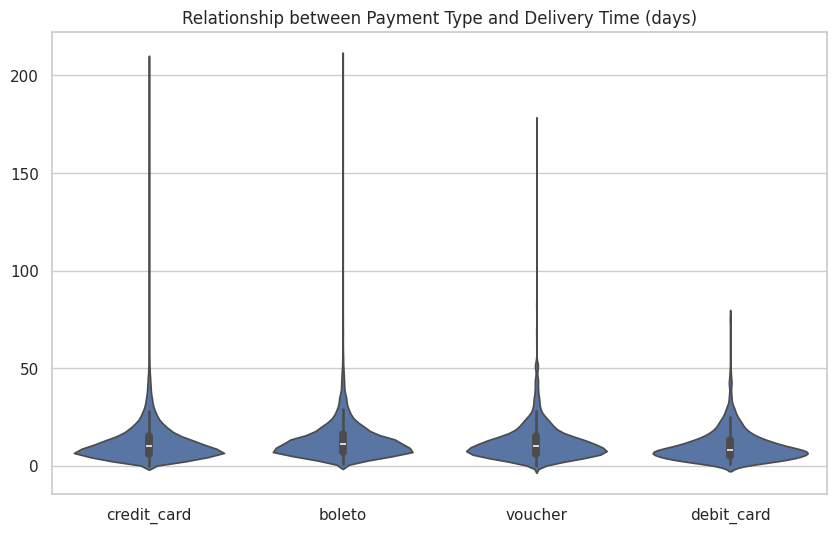

In [ ]:
# Gabungkan data order_payments dan orders
merged_payment_delivery = pd.merge(order_payments_df, orders_df, on='order_id', how='inner')

# Hitung selisih waktu pengiriman
merged_payment_delivery['delivery_time'] = (merged_payment_delivery['order_delivered_customer_date'] - merged_payment_delivery['order_purchase_timestamp']).dt.days

# Buat violin diagram
plt.figure(figsize=(10, 6))
sns.violinplot(x='payment_type', y='delivery_time', data=merged_payment_delivery)
plt.title('Relationship between Payment Type and Delivery Time (days)')
plt.xlabel('')
plt.ylabel('')
plt.show()

Insight: Waktu pengiriman serupa di semua metode pembayaran.

###4. Ulasan dan Kepuasan Pelanggan

####P8: Bagaimana distribusi rating ulasan pelanggan? Apakah mayoritas ulasan bernada positif atau negatif?

<ipython-input-81-70978913c589>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='review_score', data=order_reviews_df, palette="Blues") # Use the Blues palette


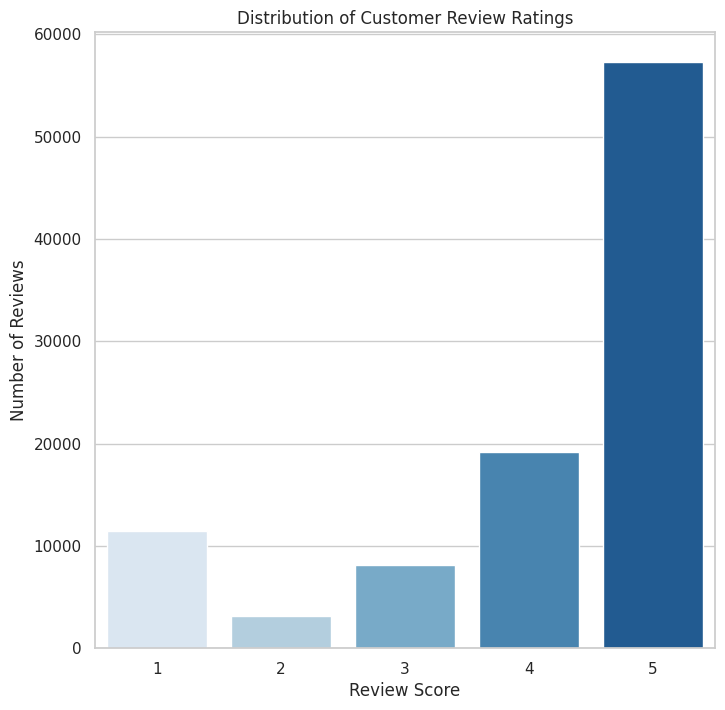

In [ ]:
# P8 Visualization: Distribution of Customer Review Ratings
plt.figure(figsize=(8, 8))
ax = sns.countplot(x='review_score', data=order_reviews_df, palette="Blues") # Use the Blues palette
plt.title('Distribution of Customer Review Ratings')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')
plt.show()

Insight: Sebagian besar ulasan diberi nilai 5, menunjukkan kepuasan pelanggan yang tinggi.

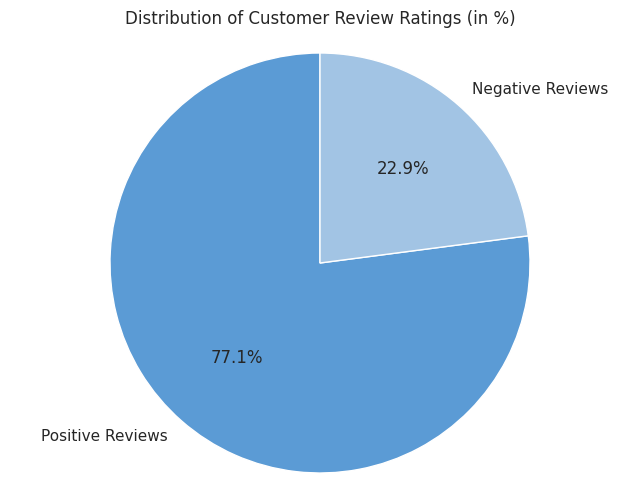

In [ ]:
# Calculate positive and negative review percentages
positive_reviews = order_reviews_df[order_reviews_df['review_score'] >= 4]
negative_reviews = order_reviews_df[order_reviews_df['review_score'] < 4]

positive_percentage = (len(positive_reviews) / len(order_reviews_df)) * 100
negative_percentage = (len(negative_reviews) / len(order_reviews_df)) * 100

# Create the pie chart
labels = ['Positive Reviews', 'Negative Reviews']
sizes = [positive_percentage, negative_percentage]
colors = ['#5B9BD5', '#A2C4E4'] # Using the same color palette

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Customer Review Ratings (in %)')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

Insight: 77,1% ulasan bersifat positif, menandakan kepuasan pelanggan yang kuat.

####P9: Apakah ada perbedaan waktu pengiriman antara pesanan yang diberi ulasan positif dan negatif?

<ipython-input-83-e4d037e5c68f>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='review_sentiment', y='delivery_time', data=average_delivery_time, palette=['#5B9BD5', '#A2C4E4'])


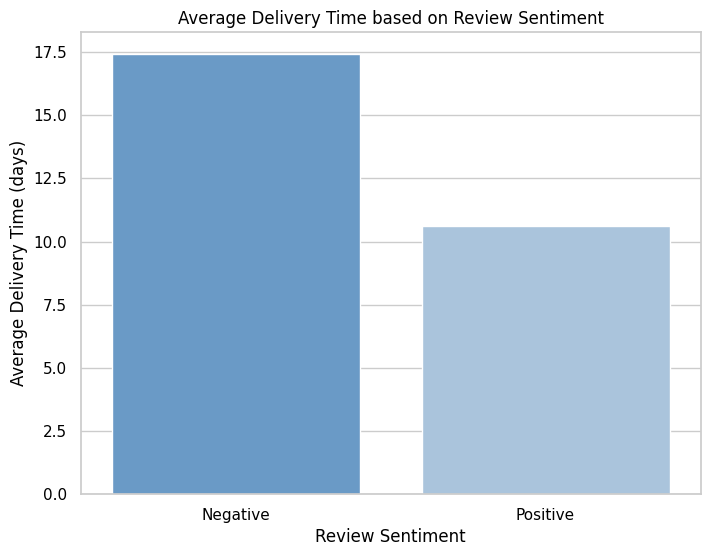

In [ ]:
# Merge necessary DataFrames
merged_df = pd.merge(orders_df, order_reviews_df, on='order_id', how='inner')

# Calculate delivery time
merged_df['delivery_time'] = (merged_df['order_delivered_customer_date'] - merged_df['order_purchase_timestamp']).dt.days

# Define positive and negative reviews
merged_df['review_sentiment'] = merged_df['review_score'].apply(lambda x: 'Positive' if x >= 4 else 'Negative')

# Group data and calculate average delivery time for each review sentiment
average_delivery_time = merged_df.groupby('review_sentiment')['delivery_time'].mean().reset_index()

# Plotting
plt.figure(figsize=(8, 6))
ax = sns.barplot(x='review_sentiment', y='delivery_time', data=average_delivery_time, palette=['#5B9BD5', '#A2C4E4'])
plt.title('Average Delivery Time based on Review Sentiment', color='black')
plt.xlabel('Review Sentiment', color='black')
plt.ylabel('Average Delivery Time (days)', color='black')
plt.xticks(color='black')
plt.yticks(color='black')
plt.show()

Insight: Ulasan negatif terkait dengan waktu pengiriman rata-rata yang jauh lebih lama (17,5 hari) dibandingkan dengan ulasan positif (sekitar 11 hari).

###5. Pengiriman

####P10: Berapa rata-rata waktu pengiriman berdasarkan kategori produk?

#####1. Top 5 Product Categories by Longest Average Delivery Time

<ipython-input-84-6fa35909e779>:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='delivery_time', y='product_category_name_english', data=top_5_categories, palette=colors)


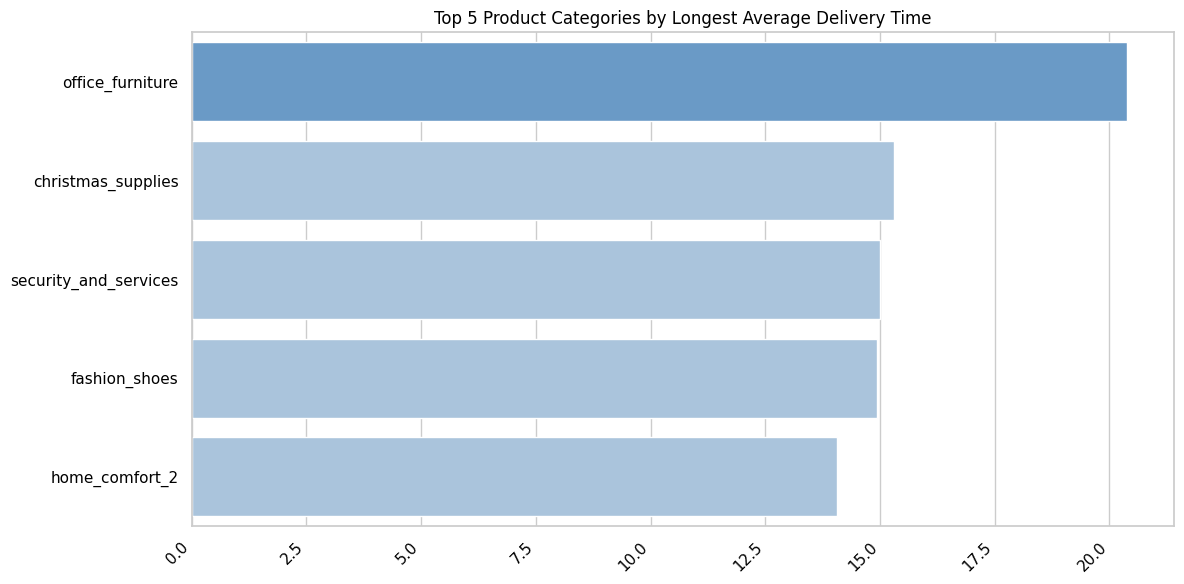

In [ ]:
# Merge necessary DataFrames
merged_df = pd.merge(orders_df, order_items_df, on='order_id', how='inner')
merged_df = pd.merge(merged_df, products_df, on='product_id', how='inner')
merged_df = pd.merge(merged_df, product_category_name_translations_df, on='product_category_name', how='inner')

# Calculate delivery time
merged_df['delivery_time'] = (merged_df['order_delivered_customer_date'] - merged_df['order_purchase_timestamp']).dt.days

# Group data and calculate average delivery time for each product category
average_delivery_time_by_category = merged_df.groupby('product_category_name_english')['delivery_time'].mean().reset_index()

# Sort by average delivery time in descending order and get the top 5
top_5_categories = average_delivery_time_by_category.sort_values(by='delivery_time', ascending=False).head(5)

# Define custom color palette
colors = ['#5B9BD5' if i == top_5_categories['delivery_time'].idxmax() else '#A2C4E4' for i in top_5_categories.index]

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x='delivery_time', y='product_category_name_english', data=top_5_categories, palette=colors)
plt.title('Top 5 Product Categories by Longest Average Delivery Time', color='black')
plt.xlabel('', color='black')
plt.ylabel('', color='black')
plt.xticks(rotation=45, ha='right', color='black')
plt.yticks(color='black')
plt.tight_layout()
plt.show()

Insight: *office_furniture* memiliki waktu pengiriman terlama (20 hari), diikuti oleh *christmas_supplies* dan *security_and_services*.

#####2. Top 5 Product Categories By Fastest Average Delivery Time

<ipython-input-85-eec621687228>:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='delivery_time', y='product_category_name_english', data=top_5_categories, palette=colors)


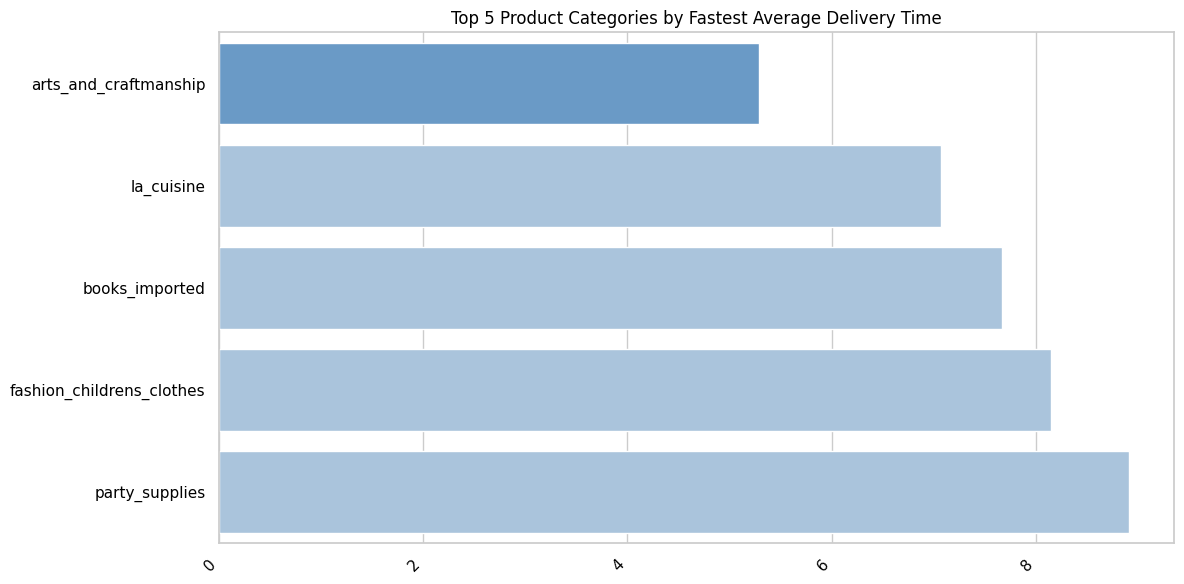

In [ ]:
# Calculate delivery time
merged_df['delivery_time'] = (merged_df['order_delivered_customer_date'] - merged_df['order_purchase_timestamp']).dt.days

# Group data and calculate average delivery time for each product category
average_delivery_time_by_category = merged_df.groupby('product_category_name_english')['delivery_time'].mean().reset_index()

# Sort by average delivery time in ascending order and get the top 5
top_5_categories = average_delivery_time_by_category.sort_values(by='delivery_time', ascending=True).head(5)

# Define custom color palette
colors = ['#5B9BD5' if i == top_5_categories['delivery_time'].idxmin() else '#A2C4E4' for i in top_5_categories.index]

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x='delivery_time', y='product_category_name_english', data=top_5_categories, palette=colors)
plt.title('Top 5 Product Categories by Fastest Average Delivery Time', color='black')
plt.xlabel('', color='black')
plt.ylabel('', color='black')
plt.xticks(rotation=45, ha='right', color='black')
plt.yticks(color='black')
plt.tight_layout()
plt.show()

Insight: Kategori seperti *arts_and_craftsmanship* (sekitar 5 hari) dan *la_cuisine* memiliki waktu pengiriman tercepat.

####P11: Apakah terdapat keterlambatan pengiriman yang sering terjadi pada kategori produk tertentu?

<ipython-input-86-af1a876f54fb>:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='delay_percentage', y='product_category_name_english', data=top_10_delayed_categories, palette=colors)


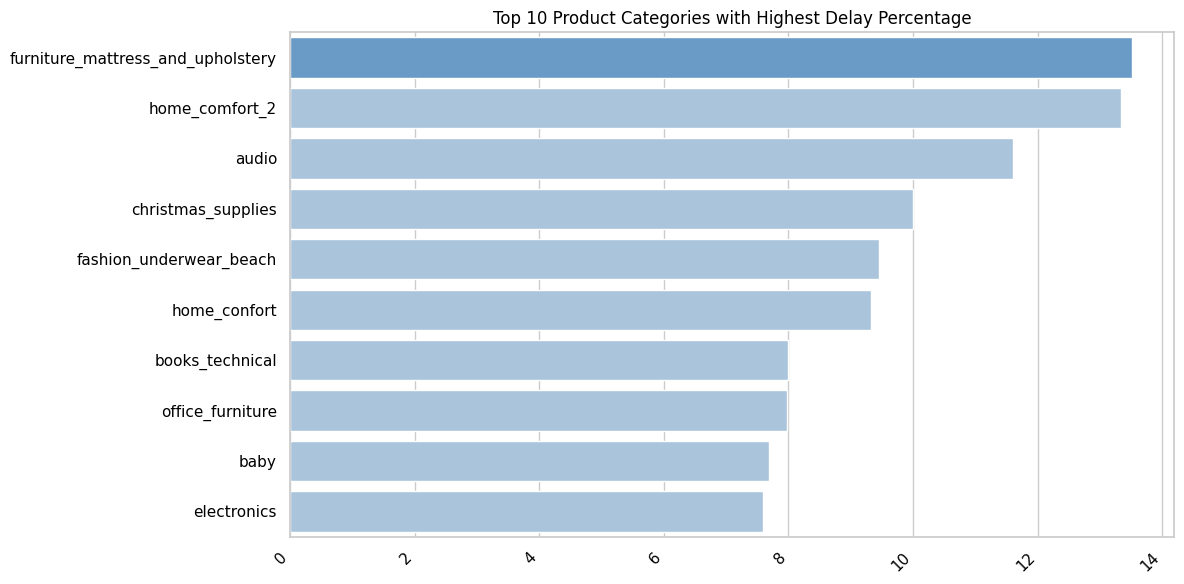

In [ ]:
# Merge necessary DataFrames
merged_df = pd.merge(orders_df, order_items_df, on='order_id', how='inner')
merged_df = pd.merge(merged_df, products_df, on='product_id', how='inner')
merged_df = pd.merge(merged_df, product_category_name_translations_df, on='product_category_name', how='inner')

# Calculate delivery time difference
merged_df['delivery_time_diff'] = (merged_df['order_delivered_customer_date'] - merged_df['order_estimated_delivery_date']).dt.days

# Identify delayed deliveries
merged_df['is_delayed'] = merged_df['delivery_time_diff'] > 0

# Group by product category and calculate the percentage of delayed deliveries
delay_percentage_by_category = merged_df.groupby('product_category_name_english')['is_delayed'].mean() * 100
delay_percentage_by_category = delay_percentage_by_category.reset_index()
delay_percentage_by_category = delay_percentage_by_category.rename(columns={'is_delayed': 'delay_percentage'})

# Sort by delay percentage in descending order and get the top 10
top_10_delayed_categories = delay_percentage_by_category.sort_values(by='delay_percentage', ascending=False).head(10)

# Define custom color palette
colors = ['#5B9BD5' if i == top_10_delayed_categories['delay_percentage'].idxmax() else '#A2C4E4' for i in top_10_delayed_categories.index]

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x='delay_percentage', y='product_category_name_english', data=top_10_delayed_categories, palette=colors)
plt.title('Top 10 Product Categories with Highest Delay Percentage', color='black')
plt.xlabel('', color='black')
plt.ylabel('', color='black')
plt.xticks(rotation=45, ha='right', color='black')
plt.yticks(color='black')
plt.tight_layout()
plt.show()

Insight: *furniture_mattress_and_upholstery* dan *home_comfort_2* memiliki persentase keterlambatan tertinggi (sekitar 12–13%).

####P12: Berapa persentase pengiriman yang dilakukan tepat waktu dibandingkan dengan yang terlambat?

In [101]:
# Buat kolom otd_status
orders_df['otd_status'] = orders_df.apply(
    lambda row: 'on-time' if row['order_delivered_customer_date'] <= row['order_estimated_delivery_date'] else 'late',
    axis=1
)

In [104]:
# Hitung jumlah masing-masing status
status_counts = orders_df['otd_status'].value_counts()

status_counts

,count
otd_status,
on-time,88635
late,7826


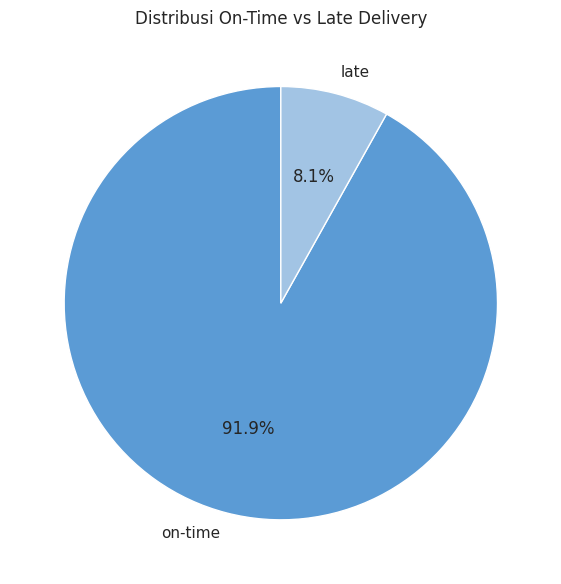

In [106]:
# Buat diagram lingkaran
plt.figure(figsize=(6, 6))
colors = ['#5B9BD5', '#A2C4E4']
status_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=colors, labels=status_counts.index)
plt.title('Distribusi On-Time vs Late Delivery')
plt.ylabel('')
plt.tight_layout()
plt.show()

Insight: Sebanyak 91.9% pengiriman berhasil dilakukan tepat waktu, sementara hanya 8.1% yang mengalami keterlambatan.



---



##6. RFM Analysis

* Recency (Ketepatan Waktu Transaksi): Mengukur seberapa baru pelanggan terakhir kali melakukan pembelian di platform Olist.
* Frequency (Frekuensi Pembelian): Menilai seberapa sering pelanggan melakukan transaksi dalam periode waktu tertentu.
* Monetary (Nilai Transaksi): Mengukur seberapa besar total uang yang telah dibelanjakan oleh pelanggan selama periode yang dianalisis.

###6. 1. RFM Processing

In [ ]:
# Gabungkan dan proses data
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
merged_df = orders_df.merge(order_payments_df, on='order_id').merge(customers_df, on='customer_id')
reference_date = merged_df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

In [ ]:
# Hitung RFM
rfm_df = merged_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,
    'order_id': 'nunique',
    'payment_value': 'sum'
}).reset_index()
rfm_df.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

In [ ]:
# Skoring 1-4 agar sesuai dengan aturan segmentasi
rfm_df['R'] = pd.qcut(rfm_df['Recency'], 4, labels=[1, 2, 3, 4]).astype(int)
rfm_df['F'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), 4, labels=[4, 3, 2, 1]).astype(int)
rfm_df['M'] = pd.qcut(rfm_df['Monetary'], 4, labels=[4, 3, 2, 1]).astype(int)

In [ ]:
# Buat kolom kombinasi segmentasi
rfm_df['Segment'] = rfm_df['R'].astype(str) + rfm_df['F'].astype(str) + rfm_df['M'].astype(str)
rfm_df['Segment'] = rfm_df['Segment'].astype(int)

In [ ]:
# Fungsi segmentasi berdasarkan segmentasi yang kamu berikan
def segment(x):
    if x == 111:
        return 'Best'
    elif x in [112, 211, 122, 222]:
        return 'Potential'
    elif x in [121,131,141,221,231,241,311,321,331,341,411,421,431,441]:
        return 'Big Spender'
    elif x in [113,114,212,213,214,312,313,314,412,413,414]:
        return 'Loyal'
    elif x in [322,323,324,332,333,334,342,343,344]:
        return 'Almost Lost'
    elif x in [422,423,424,432,433,442]:
        return 'Lost Customers'
    elif x in [444,443,434]:
        return 'Lost Cheap'
    else:
        return 'Others'

In [ ]:
# Terapkan fungsi segmentasi
rfm_df['Class'] = rfm_df['Segment'].apply(segment)

In [ ]:
# Tampilkan hasil akhir
rfm_df[[
    'customer_unique_id', 'Recency', 'Frequency', 'Monetary',
    'R', 'F', 'M', 'Segment', 'Class'
]]

,customer_unique_id,Recency,Frequency,Monetary,R,F,M,Segment,Class
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,1,4,2,142,Others
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,2,4,4,244,Others
2,0000f46a3911fa3c0805444483337064,537,1,86.22,4,4,3,443,Lost Cheap
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,3,4,4,344,Almost Lost
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,3,4,1,341,Big Spender
...,...,...,...,...,...,...,...,...,...
93336,fffcf5a5ff07b0908bd4e2dbc735a684,447,1,2067.42,4,1,1,411,Big Spender
93337,fffea47cd6d3cc0a88bd621562a9d061,262,1,84.58,3,1,3,313,Loyal
93338,ffff371b4d645b6ecea244b27531430a,568,1,112.46,4,1,2,412,Loyal
93339,ffff5962728ec6157033ef9805bacc48,119,1,133.69,2,1,2,212,Loyal


**Customer Segment Guide (RFM-Based)**

- **111	= Best Customers**

Pelanggan terbaik di semua aspek — mereka baru saja belanja, sering, dan nilai belanjanya tinggi. Harus diprioritaskan, diberikan apresiasi khusus seperti loyalty program atau reward eksklusif.

- **112, 122, 211, 222 =	Potential Customers**

Pelanggan ini cukup aktif (frekuensi tinggi) dan tidak terlalu lama dari transaksi terakhir, namun nilai belanjanya belum besar. Mereka sangat potensial untuk ditingkatkan menjadi pelanggan terbaik. Butuh sentuhan promosi dan nurturing agar lebih sering dan lebih besar dalam pembelanjaan berikutnya.

- **XX1	= Big Spender**

Mereka mengeluarkan uang yang besar saat berbelanja, terlepas dari seberapa sering atau kapan terakhir kali mereka bertransaksi. Segmen ini layak diberi perhatian karena kontribusinya tinggi secara finansial, meskipun tidak rutin.

- **X1X	= Loyal Customers**

Ciri khasnya adalah frekuensi belanja yang tinggi. Mereka mungkin tidak belanja mahal atau baru, tapi kesetiaan tinggi membuat mereka sangat berharga untuk dijaga.

- **3XX	= Almost Lost**

Pelanggan dengan skor Recency = 3, artinya sudah hampir 6 bulan tidak bertransaksi. Masih memungkinkan untuk ditarik kembali, tapi perlu pertimbangan strategi: apakah layak dialokasikan budget atau tidak.

- **4XX	= Lost Customers**

Sudah lebih dari 1 tahun tidak berbelanja. Ini segmen "hilang" dan keputusan untuk melakukan reaktivasi sebaiknya berdasarkan kebijakan manajemen. Bisa dilakukan dengan low-cost reactivation campaign jika diperlukan.

- **434, 443, 444	= Lost & Cheap**

Tidak hanya sudah sangat lama tidak belanja, tapi juga nilai pembeliannya tergolong kecil. Tidak disarankan untuk dialokasikan anggaran pemasaran, karena return-nya sangat rendah.

- **Lainnya (1XX & 2XX)	= Others**

Mereka mungkin baru mencoba belanja atau belum menunjukkan potensi kuat. Saat ini belum perlu perlakuan khusus, biarkan mereka menjelajahi produk dan layanan terlebih dahulu. Jika mereka kembali, bisa naik ke segmen yang lebih strategis.



---



**Analisis Lanjutan dari Segmentasi RFM: Kasus Big Spender dengan Recency Tinggi (311 & 411)**

Dalam segmentasi yang kita bangun sebelumnya, ada kombinasi skor seperti 311 dan 411 yang secara teknis bisa saja masuk kategori “Almost Lost” atau “Lost Customers” karena nilai Recency mereka tinggi (mereka sudah cukup lama tidak melakukan pembelian).

Namun dalam analisis ini, pelanggan seperti mereka tetap masuk ke kategori Big Spender. Kenapa?

Kemungkinan besar pelanggan ini punya perilaku pembelian yang tidak reguler atau bukan tipe pembelian harian/bulanan.
Misalnya:
- Mereka mungkin membeli produk dengan harga tinggi dan daya tahan lama.
- Produk semacam itu tidak perlu dibeli terlalu sering, tapi saat dibeli, nilainya sangat besar.

Contoh:

Jika Olist menjual fashion branded seperti handbag Chanel, tas Louis Vuitton, atau furniture premium, wajar jika pelanggan seperti ini hanya belanja sekali dalam satu musim (seasonal) — tetapi sekali beli langsung jutaan rupiah.

Kesimpulan:

Jadi walaupun Recency-nya tinggi (lama tidak belanja), nilai belanja (Monetary) dan potensi loyalitas (karena pernah beli besar) membuat mereka tetap layak diperlakukan sebagai Big Spender — dan mungkin bisa ditargetkan kembali saat produk baru rilis di musim selanjutnya.

###6. 2. Specification + Data Checking

In [ ]:
# Checking the data
rfm_df[rfm_df['Segment'] == 111].sort_values('Monetary', ascending=False).head(10)

,customer_unique_id,Recency,Frequency,Monetary,R,F,M,Segment,Class
73115,c8460e4251689ba205045f3ea17884a1,22,4,4655.91,1,1,1,111,Best
86838,edde2314c6c30e864a128ac95d6b2112,26,1,4513.32,1,1,1,111,Best
73813,ca27f3dac28fb1063faddd424c9d95fa,32,1,4163.51,1,1,1,111,Best
87725,f0767ae738c3d90e7b737d7b8b8bb4d1,107,1,3979.55,1,1,1,111,Best
75259,ce3fe361f9e68bf0a813baaae1334d01,14,1,3351.35,1,1,1,111,Best
90657,f886a3f43af9ac928fbb4b56436c528c,15,1,3076.13,1,1,1,111,Best
93329,fff5eb4918b2bf4b2da476788d42051c,58,1,2844.96,1,1,1,111,Best
88010,f140f377d666848e3712b51a2734d120,31,1,2713.36,1,1,1,111,Best
89127,f44ffa618df5f8a65899275c93b14ae2,110,1,2638.64,1,1,1,111,Best
44950,7b0eaf68a16e4808e5388c67345033c9,103,2,2340.08,1,1,1,111,Best


In [ ]:
# Data checking berdasarkan quartile
data_check = rfm_df[['Recency', 'Frequency', 'Monetary', 'R', 'F', 'M']]
data_check1 = data_check[(data_check['R'] == 1) & (data_check['F'] == 1) & (data_check['M'] == 1)]
data_check2 = data_check[(data_check['R'] == 2) & (data_check['F'] == 2) & (data_check['M'] == 2)]
data_check3 = data_check[(data_check['R'] == 3) & (data_check['F'] == 3) & (data_check['M'] == 3)]
data_check4 = data_check[(data_check['R'] == 4) & (data_check['F'] == 4) & (data_check['M'] == 4)]

In [ ]:
data_check1.describe()

,Recency,Frequency,Monetary,R,F,M
count,1780.000000,1780.000000,1780.000000,1780.0,1780.0,1780.0
mean,58.638764,1.355618,408.264854,1.0,1.0,1.0
std,32.802651,0.711226,375.731489,0.0,0.0,0.0
min,1.000000,1.000000,182.830000,1.0,1.0,1.0
25%,29.000000,1.000000,220.995000,1.0,1.0,1.0
50%,57.000000,1.000000,285.960000,1.0,1.0,1.0
75%,86.000000,2.000000,435.685000,1.0,1.0,1.0
max,114.000000,15.000000,4655.910000,1.0,1.0,1.0


- data_check1:
  - Recency = 1 hari – 114 hari → selisih 113 hari
  - Frequency = 1 – 15 kali → selisih 14 kali
  - Monetary = 182.83 – 4655.91 → selisih 4.473,08

Insight: Ini adalah pelanggan prioritas utama. Mereka belanja sering, baru-baru ini, dan nilai belanjanya besar. Ideal untuk loyalty program atau VIP treatment.

In [ ]:
data_check2.describe()

,Recency,Frequency,Monetary,R,F,M
count,1448.000000,1448.0,1448.000000,1448.0,1448.0,1448.0
mean,166.112569,1.0,142.109744,2.0,2.0,2.0
std,30.218859,0.0,21.355233,0.0,0.0,0.0
min,115.000000,1.0,107.800000,2.0,2.0,2.0
25%,139.000000,1.0,123.527500,2.0,2.0,2.0
50%,166.000000,1.0,139.615000,2.0,2.0,2.0
75%,192.000000,1.0,161.860000,2.0,2.0,2.0
max,219.000000,1.0,182.420000,2.0,2.0,2.0


- data_check2:
  - Recency: 115 – 219 hari → selisih 104 hari
  - Frequency: hanya 1 kali
  - Monetary: 107.80 – 182.42 → selisih 74,62

Insight: Pelanggan ini masih cukup aktif tapi hanya melakukan satu transaksi. Nilai transaksinya juga menengah. Cocok untuk nurturing campaign agar mereka jadi lebih loyal.

In [ ]:
data_check3.describe()

,Recency,Frequency,Monetary,R,F,M
count,1508.000000,1508.0,1508.000000,1508.0,1508.0,1508.0
mean,278.101459,1.0,82.947487,3.0,3.0,3.0
std,35.084801,0.0,13.503001,0.0,0.0,0.0
min,220.000000,1.0,63.090000,3.0,3.0,3.0
25%,252.000000,1.0,71.605000,3.0,3.0,3.0
50%,276.000000,1.0,81.115000,3.0,3.0,3.0
75%,307.000000,1.0,94.400000,3.0,3.0,3.0
max,346.000000,1.0,107.780000,3.0,3.0,3.0


- data_check3:
  - Recency: 220 – 346 hari → selisih 126 hari
  - Frequency: hanya 1 kali
  - Monetary: 63.09 – 107.78 → selisih 44,69

Insight: Mereka adalah pelanggan lama yang jarang kembali. Nilai belanjanya rendah. Perlu diberi trigger seperti voucher atau diskon comeback.

In [ ]:
data_check4.describe()

,Recency,Frequency,Monetary,R,F,M
count,1519.000000,1519.0,1519.000000,1519.0,1519.0,1519.0
mean,455.072416,1.0,43.894812,4.0,4.0,4.0
std,73.013634,0.0,11.431785,0.0,0.0,0.0
min,347.000000,1.0,14.130000,4.0,4.0,4.0
25%,394.000000,1.0,34.465000,4.0,4.0,4.0
50%,447.000000,1.0,44.420000,4.0,4.0,4.0
75%,512.000000,1.0,53.610000,4.0,4.0,4.0
max,695.000000,1.0,63.000000,4.0,4.0,4.0


- data_check4:
  - Recency: 347 – 695 hari → selisih 348 hari
  - Frequency: hanya 1 kali
  - Monetary: 14.13 – 63.00 → selisih 48,87

Insight: Ini adalah pelanggan yang sudah sangat lama tidak bertransaksi dan nilai belanjanya kecil. Mungkin tidak layak untuk effort pemasaran besar, tapi bisa ditarget untuk email reaktivasi ringan.

###6. 3. Customer Segment Visualization

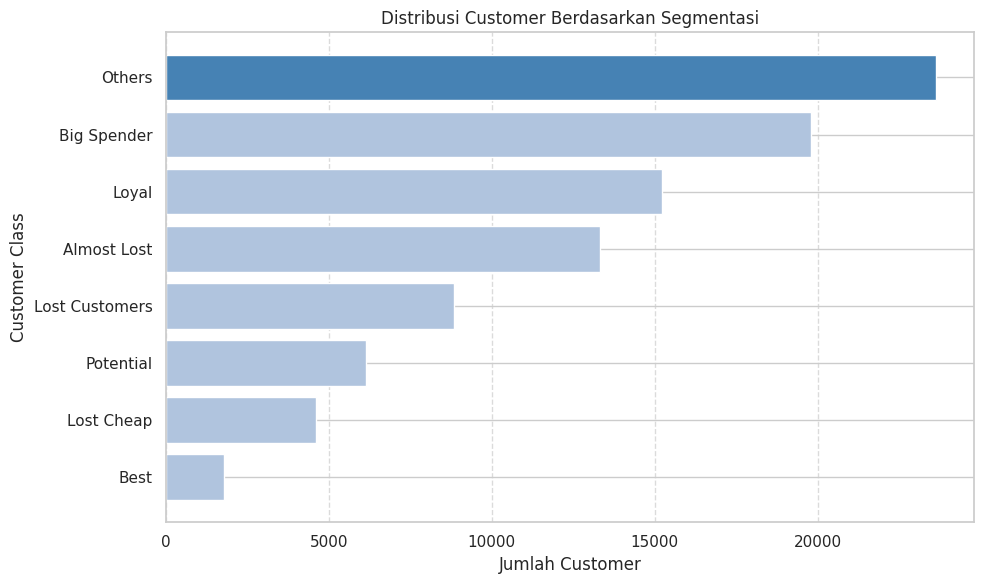

In [ ]:
# Hitung jumlah customer per segmentasi
segment_counts = rfm_df['Class'].value_counts()

# Warna batang: satu tertinggi biru tua, sisanya biru muda
max_segment = segment_counts.idxmax()
colors = ['steelblue' if seg == max_segment else 'lightsteelblue' for seg in segment_counts.index]

# Plot horizontal dan urutan sesuai data (tidak diurutkan ulang)
plt.figure(figsize=(10, 6))
bars = plt.barh(segment_counts.index, segment_counts.values, color=colors)
plt.title('Distribusi Customer Berdasarkan Segmentasi')
plt.xlabel('Jumlah Customer')
plt.ylabel('Customer Class')

plt.gca().invert_yaxis()  # agar bar tertinggi tetap di atas
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Insight: Berdasarkan analisis RFM yang telah dilakukan, distribusi pelanggan terbanyak berada pada segmen 'Others', menunjukkan mayoritas pelanggan belum menunjukkan pola loyalitas atau nilai transaksi yang signifikan. Segmen 'Big Spender' dan 'Loyal' menjadi kelompok strategis terbesar setelah 'Others', menunjukkan potensi tinggi untuk retensi dan upselling.



---



##7. K-Means Clustering

###7. 1. Checking the Outliers

In [107]:
# Ambil data RFM untuk analisis outlier
data_rfm = rfm_df[['Recency', 'Frequency', 'Monetary']]
columns = ['Recency', 'Frequency', 'Monetary']

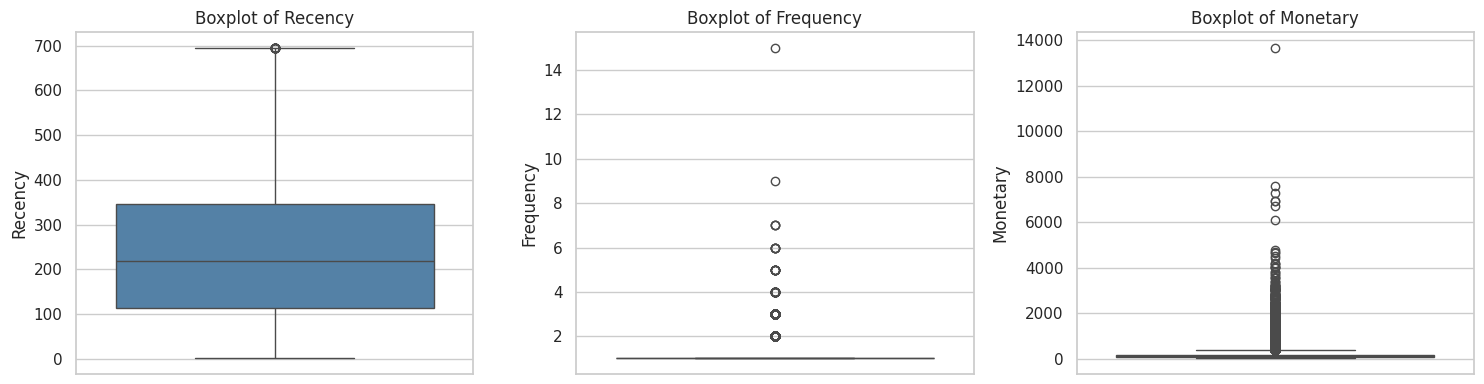

In [112]:
# Boxplot untuk deteksi outlier
import seaborn as sns
import matplotlib.pyplot as plt

def plotting_boxplot(lst):
    plt.figure(figsize=[len(lst)*5, 4])
    for i, col in enumerate(lst, 1):
        plt.subplot(1, len(lst), i)
        sns.boxplot(y=data_rfm[col], color='steelblue')
        plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

plotting_boxplot(columns)

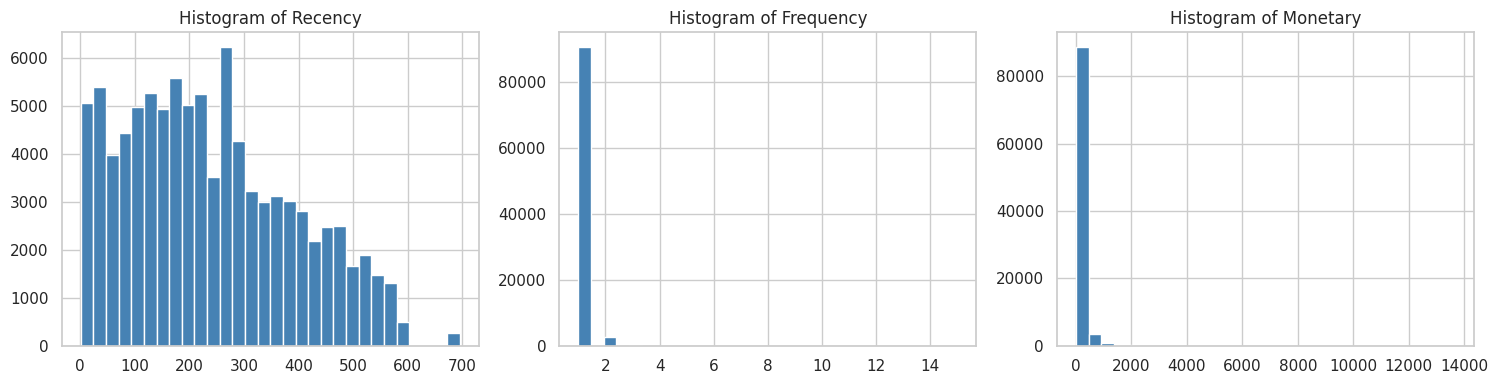

In [113]:
# Histogram untuk melihat distribusi
def plotting_histogram(lst):
    plt.figure(figsize=[len(lst)*5, 4])
    for i, col in enumerate(lst, 1):
        plt.subplot(1, len(lst), i)
        plt.hist(data_rfm[col], bins=30, color='steelblue')
        plt.title(f'Histogram of {col}')
    plt.tight_layout()
    plt.show()

plotting_histogram(columns)

In [114]:
# Statistik deskriptif
data_rfm.describe()

,Recency,Frequency,Monetary
count,93341.000000,93341.000000,93341.000000
mean,237.922531,1.033415,165.197318
std,152.577070,0.209092,226.329624
min,1.000000,1.000000,9.590000
25%,114.000000,1.000000,63.050000
50%,219.000000,1.000000,107.780000
75%,346.000000,1.000000,182.540000
max,695.000000,15.000000,13664.080000


###7. 2. Standard Scaling

In [117]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Salin data dan lakukan standardisasi
df_std = data_rfm.copy()
scale = StandardScaler()
column_all = ['Recency', 'Frequency', 'Monetary']
for kolom in column_all:
    df_std[kolom] = scale.fit_transform(np.array(df_std[kolom]).reshape(-1, 1))

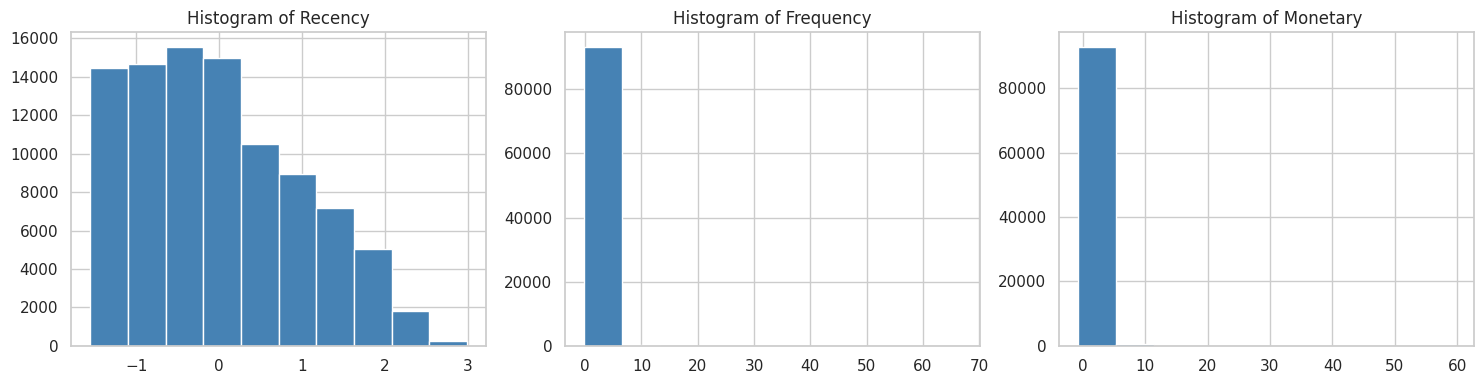

In [119]:
# Fungsi histogram setelah scaling
def plotting_boxplot(lst):
    plt.figure(figsize=[len(lst)*5, 4])
    for i, col in enumerate(lst, 1):
        plt.subplot(1, len(lst), i)
        plt.hist(df_std[col], bins=10, color='steelblue')
        plt.title(f'Histogram of {col}')
    plt.tight_layout()
    plt.show()

# Plot histogram dari data yang sudah distandardisasi
plotting_boxplot(column_all)

Insight: StandardScaler berhasil menyetarakan skala fitur RFM. Namun, distribusi Frequency dan Monetary masih sangat miring → ini berpotensi memengaruhi performa clustering. Untuk hasil clustering yang lebih baik dengan menerapkan log transformasi ke Frequency dan Monetary sebelum scaling, lalu baru di-StandardScaler setelahnya.

In [120]:
# Log transformasi untuk Frequency dan Monetary (tambah 1 biar nggak log(0))
rfm_df['Frequency_log'] = np.log1p(rfm_df['Frequency'])
rfm_df['Monetary_log'] = np.log1p(rfm_df['Monetary'])

In [121]:
# Standardisasi semua fitur log-transform + Recency
scaler = StandardScaler()
rfm_scaled = rfm_df[['Recency', 'Frequency_log', 'Monetary_log']].copy()
rfm_scaled[['Recency', 'Frequency_log', 'Monetary_log']] = scaler.fit_transform(rfm_scaled)

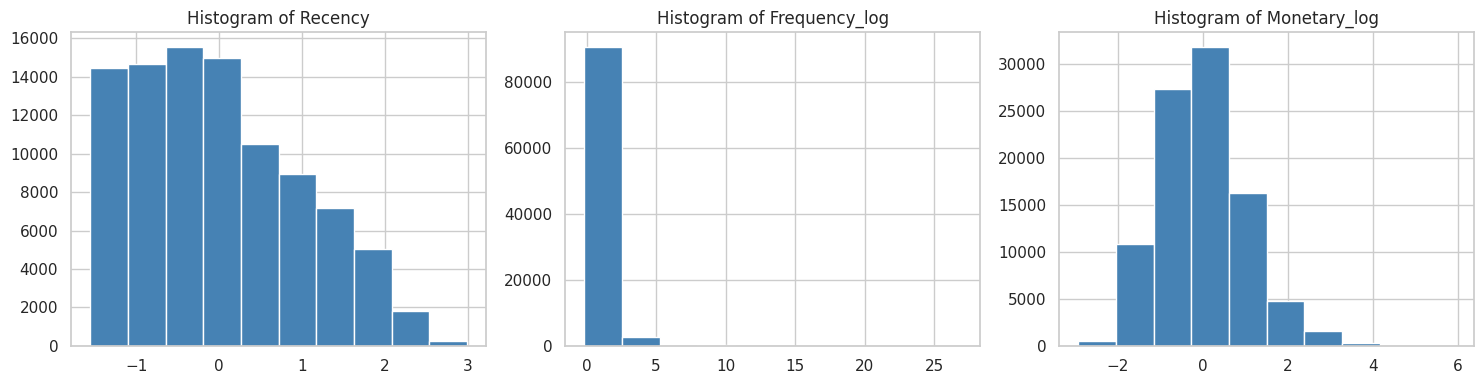

In [124]:
# Plot histogram setelah scaling dan log transform
columns = ['Recency', 'Frequency_log', 'Monetary_log']

def plot_scaled_histograms(cols):
    plt.figure(figsize=[len(cols)*5, 4])
    for i, col in enumerate(cols, 1):
        plt.subplot(1, len(cols), i)
        plt.hist(rfm_scaled[col], bins=10, color='steelblue')
        plt.title(f'Histogram of {col}')
    plt.tight_layout()
    plt.show()

plot_scaled_histograms(columns)

'Frequency_log' tetap terlihat sangat skewed ke kanan, meskipun sudah di-log dan distandardisasi. Data pada 'Monetary_log' memperlihatkan bahwa distribusi paling mendekati normal di antara ketiganya. Fitur-fitur sudah dalam skala yang seragam dan cukup stabil secara distribusi.

###7. 3. Cluster Processing

####7. 3. 1. Elbow Method

In [127]:
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import cluster
from yellowbrick.cluster import SilhouetteVisualizer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [128]:
# Gunakan data rfm_scaled (hasil log + scaled sebelumnya)
X_cluster = rfm_scaled.copy()

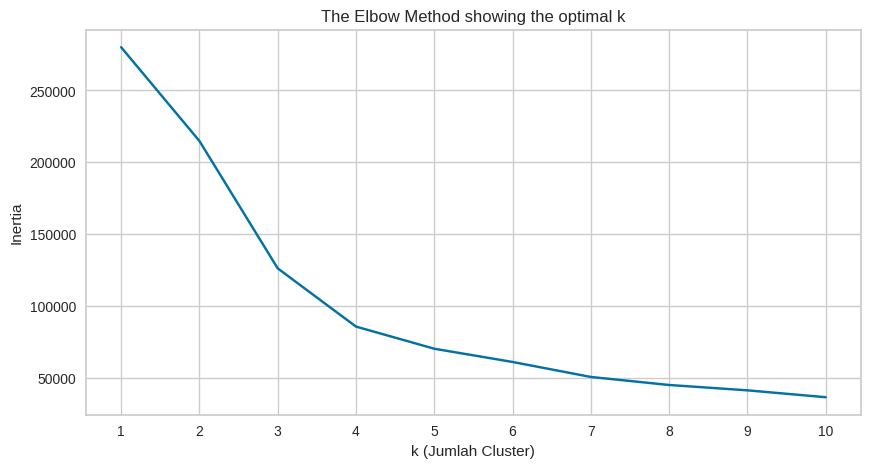

[280023.0000000006, 214846.09476847507, 126260.51167170073, 85764.70400637848, 70367.77693157205, 61165.29710444204, 50727.73247979331, 45152.07458892262, 41429.87424983471, 36641.81105128195]


In [130]:
# Elbow method
distortions = []
K = range(1, 11)

for k in K:
    kmeanModel = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeanModel.fit(X_cluster)
    distortions.append(kmeanModel.inertia_)

# Visualisasi elbow
plt.figure(figsize=(10, 5))
plt.plot(K, distortions, 'bx-')
plt.xlabel('k (Jumlah Cluster)')
plt.ylabel('Inertia')
plt.title('The Elbow Method showing the optimal k')
plt.xticks(K)
plt.grid(True)
plt.show()

print(distortions)

Titik elbow paling jelas ada di k = 3 atau k = 4, yang mengindikasikan jumlah cluster optimal di kisaran tersebut.

For k=2, the average silhouette score is 0.2843
For k=3, the average silhouette score is 0.3381
For k=4, the average silhouette score is 0.3734
For k=5, the average silhouette score is 0.3582
For k=6, the average silhouette score is 0.3204
For k=7, the average silhouette score is 0.3383
For k=8, the average silhouette score is 0.3392
For k=9, the average silhouette score is 0.3452
For k=10, the average silhouette score is 0.3394


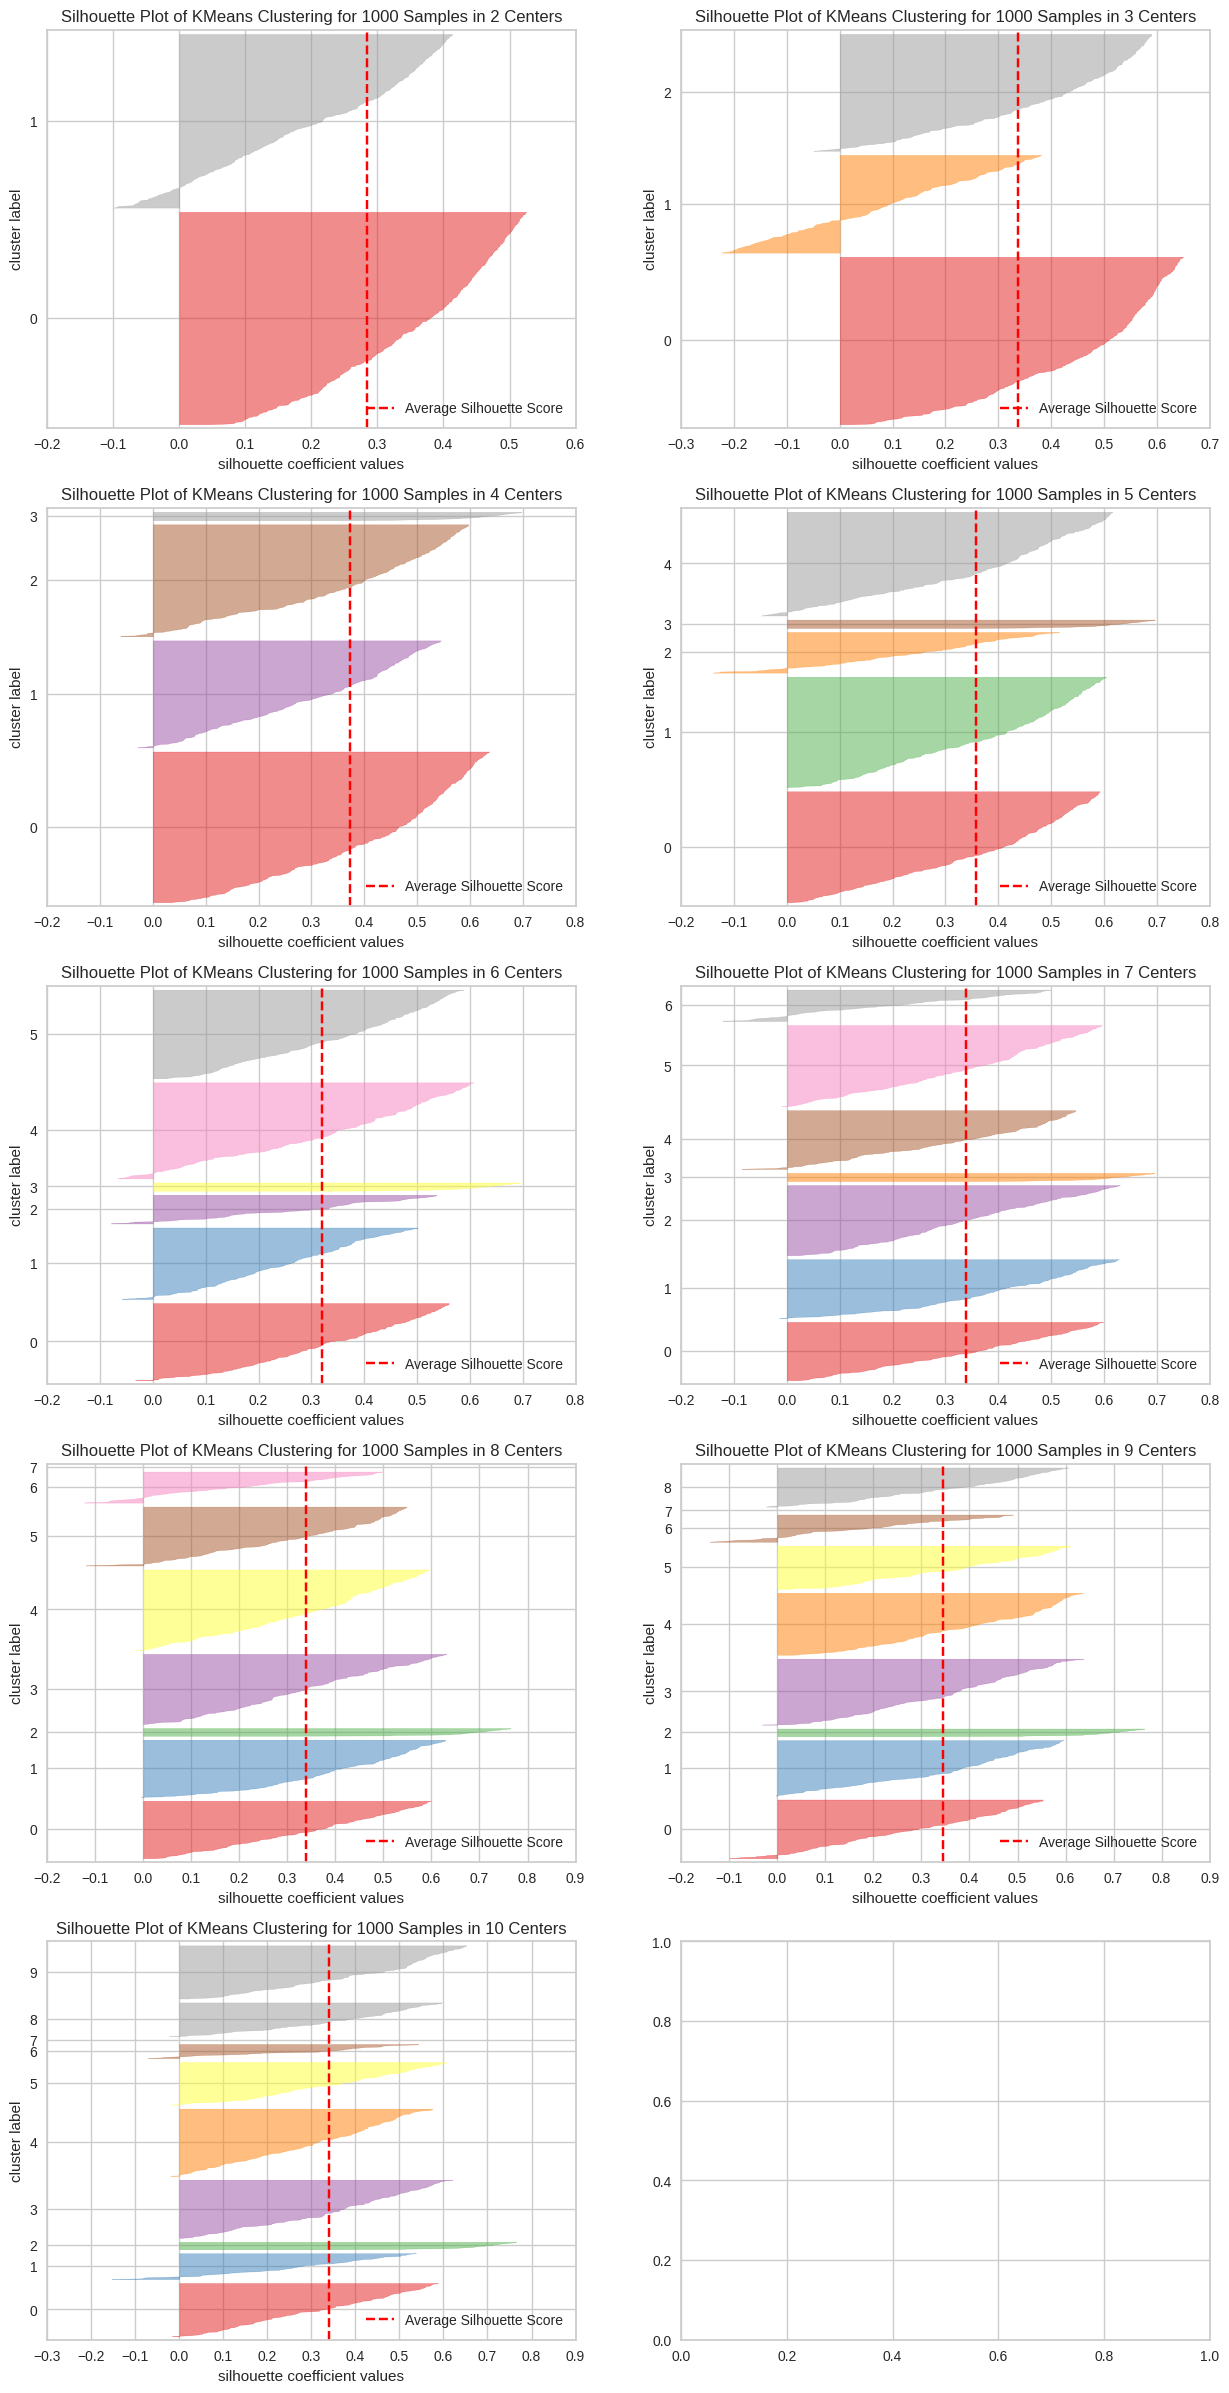

In [135]:
from yellowbrick.cluster import SilhouetteVisualizer

# Ambil sampel 1000 baris dari X_cluster
X_sampled = X_cluster.sample(n=1000, random_state=42)

# Range jumlah cluster
K = range(2, 11)
max_K = max(K)

# Buat subplot 2 kolom
fig, ax = plt.subplots(int(np.ceil(max_K / 2)), 2, figsize=(15, 30))

# Visualisasi Silhouette untuk setiap k
for n_clusters in K:
    kmeans_model = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42)
    q, mod = divmod(n_clusters, 2)

    sil = SilhouetteVisualizer(kmeans_model, is_fitted=False, ax=ax[q - 1][mod])
    sil.fit(X_sampled)
    sil.finalize()

    print(f"For k={n_clusters}, the average silhouette score is {sil.silhouette_score_:.4f}")

Skor tertinggi adalah di k = 4 (0.3734)
→ Ini artinya, pada saat jumlah cluster 4, separasi antar klaster paling baik dan klaster lebih kohesif.

Maka, berdasarkan Elbow Method dan Silhouette Score, jumlah cluster yang paling optimal adalah k = 4.

####7. 3. 2. Segment Profiling

In [136]:
# Terapkan K-Means dengan k = 4
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42)
rfm_scaled['Cluster'] = kmeans_final.fit_predict(X_cluster)

In [137]:
# Hitung jumlah dan rata-rata nilai per cluster
rfm_clustered = rfm_scaled.copy()
rfm_clustered['Cluster'] = rfm_scaled['Cluster']

In [138]:
# Gabungkan ke data RFM asli untuk profiling
rfm_profiled = rfm_df.copy()
rfm_profiled['Cluster'] = rfm_scaled['Cluster']

In [139]:
# Hitung profil per klaster
cluster_profile = rfm_profiled.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Count'})

In [140]:
# Tampilkan hasil profiling cluster
cluster_profile.reset_index(inplace=True)
cluster_profile

,Cluster,Recency,Frequency,Monetary,Count
0,0,176.042550,1.000000,321.505045,27544
1,1,146.369319,1.000000,69.963457,35996
2,2,220.264286,2.113929,308.592029,2800
3,3,424.930966,1.000000,117.835844,27001


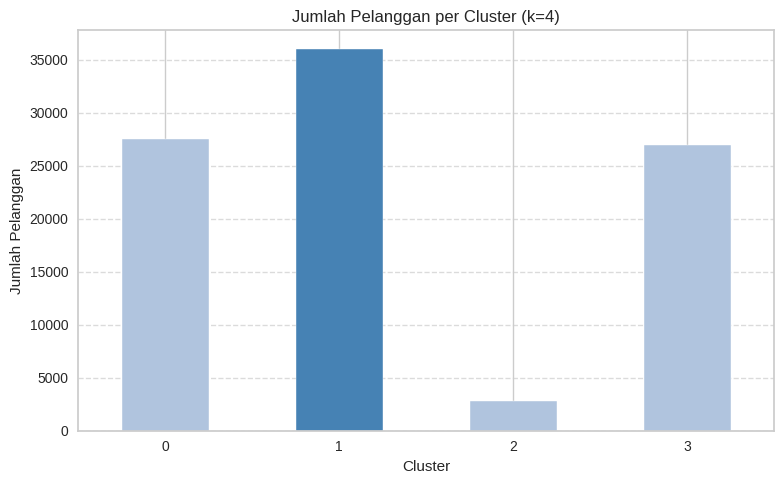

In [147]:
# Atur warna: tertinggi = steelblue, sisanya = lightsteelblue
colors = ['lightsteelblue'] * len(cluster_counts)
max_index = cluster_counts.idxmax()
colors[max_index] = 'steelblue'

# Buat ulang diagram dengan warna khusus
plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar', color=colors)
plt.title('Jumlah Pelanggan per Cluster (k=4)')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Pelanggan')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Cluster 1 merupakan cluster dengan jumlah pelanggan terbanyak, sedangkan cluster 2 merupakan cluster dengan jumlah pelanggan paling sedikit dibandingkan dengan cluster lainnya.

###7. 4. Plotting RF, MF, RM

####7. 4. 1. Recency vs Frequency

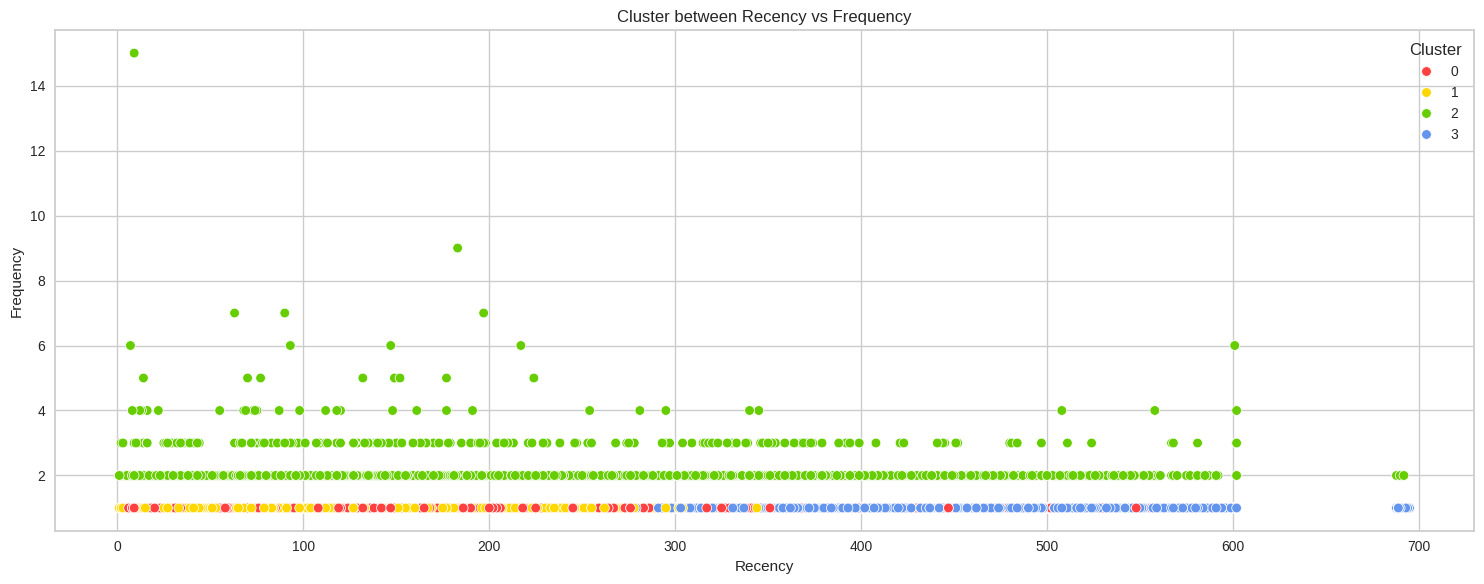

In [148]:
import seaborn as sns

# Siapkan palet warna dan data
palette = ["#FF4040", "#FFD700", "#66CD00", "#6495ED"]
data_label_4 = rfm_profiled.copy()
data_label_4['K_Cluster'] = rfm_scaled['Cluster']

# Plot Recency vs Frequency
plt.figure(figsize=(15, 6))
sns.scatterplot(data=data_label_4, x='Recency', y='Frequency', hue='K_Cluster', palette=palette)
plt.title("Cluster between Recency vs Frequency")
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

####7. 4. 2. Frequency vs Monetary

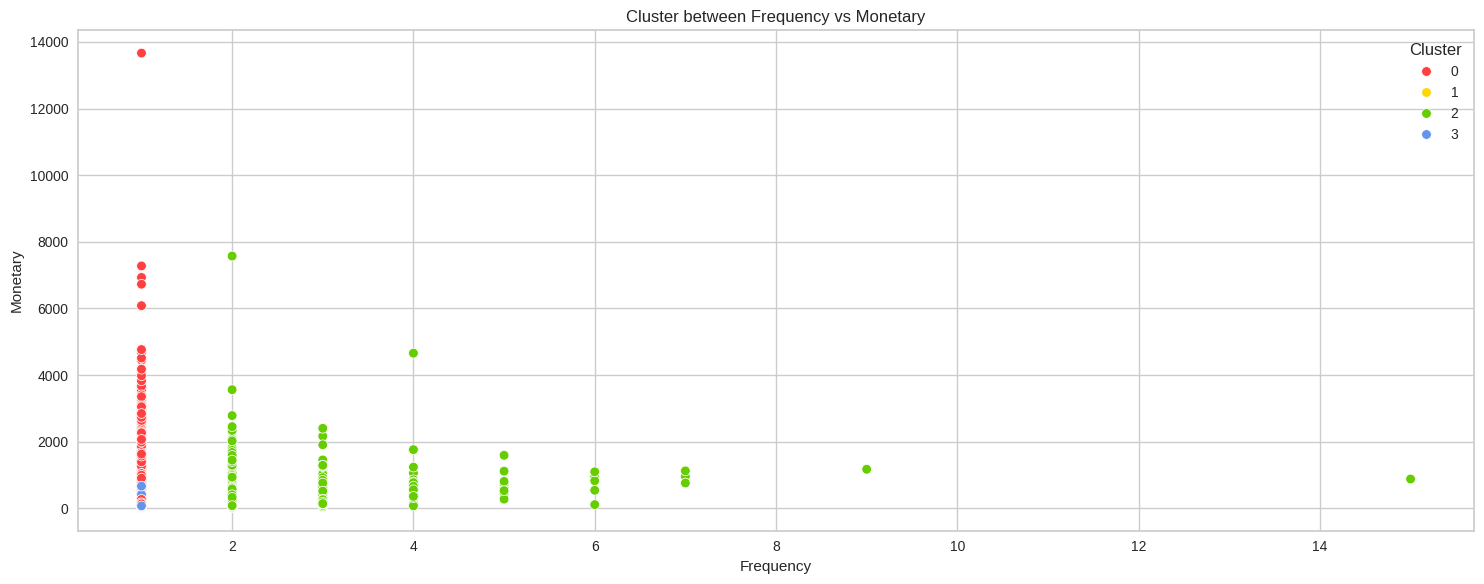

In [149]:
plt.figure(figsize=(15, 6))
sns.scatterplot(data=data_label_4, x='Frequency', y='Monetary', hue='K_Cluster', palette=palette)
plt.title("Cluster between Frequency vs Monetary")
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

####7. 4. 3. Recency vs Monetary

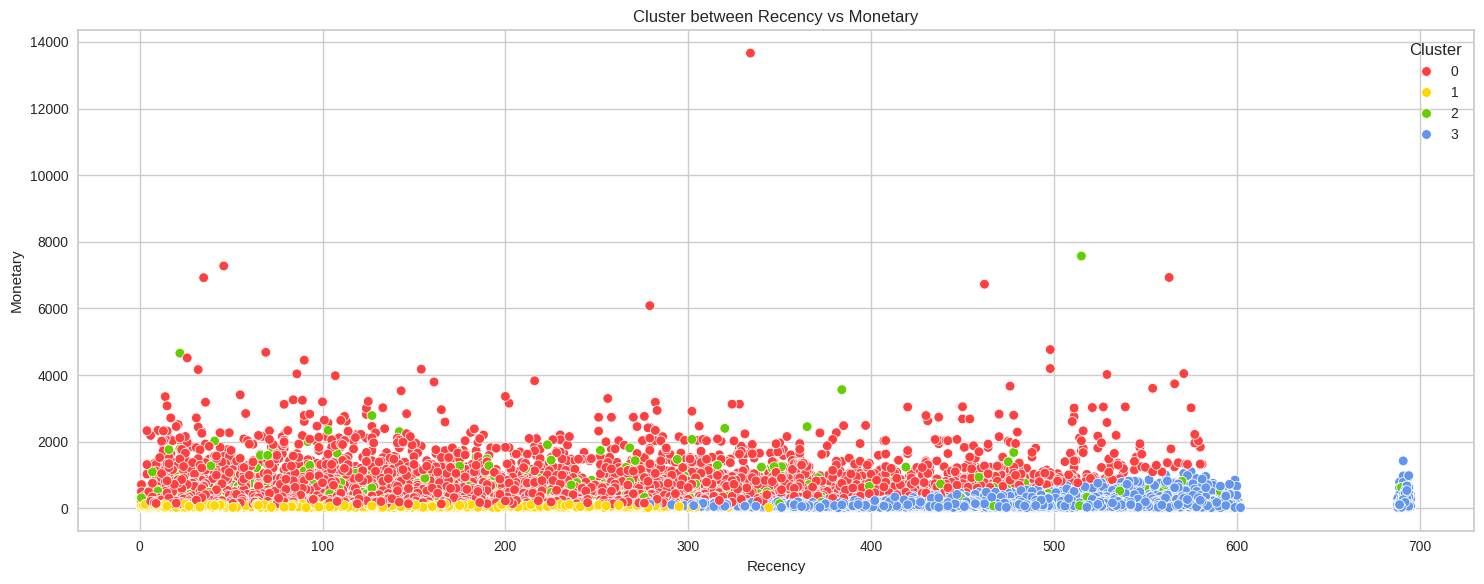

In [150]:
plt.figure(figsize=(15, 6))
sns.scatterplot(data=data_label_4, x='Recency', y='Monetary', hue='K_Cluster', palette=palette)
plt.title("Cluster between Recency vs Monetary")
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()



---



##8. Analyzing the effectiveness between K-Means clustering and RFM

###8. 1. K-Means Class Distribution

In [151]:
# List semua klaster
clusters = data_label_4['K_Cluster'].unique()

# Looping data per klaster
for k in clusters:
    cluster_data = data_label_4[data_label_4['K_Cluster'] == k]
    print(f"Cluster {k} - Total Customer: {len(cluster_data)}")

Cluster 0 - Total Customer: 27544
Cluster 1 - Total Customer: 35996
Cluster 3 - Total Customer: 27001
Cluster 2 - Total Customer: 2800


####Cluster 0

In [163]:
# Filter data untuk cluster 0
class0_4 = data_label_4[data_label_4['K_Cluster'] == 0]

# Lihat class yang unik di dalam cluster 0
class0_4['Class'].unique()

# Lihat distribusi jumlah class dalam cluster 0
class0_4['Class'].value_counts()

,count
Class,
Big Spender,15057
Potential,3752
Others,3710
Almost Lost,2239
Loyal,1526
Best,1260


####Cluster 1

In [162]:
class1_4 = data_label_4[data_label_4['K_Cluster'] == 1]
class1_4['Class'].unique()
class1_4['Class'].value_counts()

,count
Class,
Others,19903
Loyal,7665
Almost Lost,6704
Potential,1717
Lost Cheap,5
Lost Customers,2


####Cluster 2

In [164]:
class2_4 = data_label_4[data_label_4['K_Cluster'] == 2]
class2_4['Class'].unique()
class2_4['Class'].value_counts()

,count
Class,
Loyal,855
Big Spender,755
Potential,670
Best,520


####Cluster 3

In [165]:
class3_4 = data_label_4[data_label_4['K_Cluster'] == 3]
class3_4['Class'].unique()
class3_4['Class'].value_counts()

,count
Class,
Lost Customers,8845
Loyal,5163
Lost Cheap,4619
Almost Lost,4379
Big Spender,3995


Insight: K-Means mengelompokkan data berdasarkan pola kemiripan secara alami (berdasarkan jarak vektor RFM yang sudah diskalakan).

###8. 2. RFM Class Distribution

In [167]:
# Buat ulang RFMClass jika belum ada
data_label_4['RFMClass'] = (
    data_label_4['R'].astype(str) +
    data_label_4['F'].astype(str) +
    data_label_4['M'].astype(str)
)

####Cluster 0

In [175]:
# Cluster 0
class0_4 = data_label_4[data_label_4['K_Cluster'] == 0]
class0_4['RFMClass'].unique()

array(['142', '341', '242', '241', '141', '342', '441', '331', '131',
       '231', '431', '132', '232', '332', '321', '322', '121', '221',
       '222', '122', '421', '112', '311', '211', '212', '312', '111',
       '411'], dtype=object)

####Cluster 1

In [170]:
# Cluster 1
class1_4 = data_label_4[data_label_4['K_Cluster'] == 1]
class1_4['RFMClass'].unique()

array(['244', '243', '344', '143', '144', '343', '142', '342', '242',
       '444', '234', '134', '333', '233', '232', '132', '334', '133',
       '332', '434', '122', '224', '123', '323', '222', '324', '223',
       '124', '322', '424', '313', '114', '213', '314', '214', '113',
       '112', '212', '312'], dtype=object)

####Cluster 2

In [171]:
# Cluster 2
class2_4 = data_label_4[data_label_4['K_Cluster'] == 2]
class2_4['RFMClass'].unique()

array(['311', '112', '412', '211', '111', '411', '213', '212', '313',
       '114', '413', '113', '312', '414', '214', '314'], dtype=object)

####Cluster 3

In [172]:
# Cluster 3
class3_4 = data_label_4[data_label_4['K_Cluster'] == 3]
class3_4['RFMClass'].unique()

array(['443', '344', '442', '444', '342', '441', '343', '341', '433',
       '334', '432', '434', '431', '332', '333', '331', '324', '424',
       '421', '422', '322', '423', '323', '321', '414', '413', '314',
       '411', '412', '312', '313', '311'], dtype=object)

Insight:

Contoh, RFMClass = 111.

RFMClass yang sama bisa tersebar ke cluster 0 dan 2, artinya walaupun skornya sama, K-Means bisa mengelompokkan secara berbeda tergantung distribusi datanya.

### **Kesimpulan Komparatif: K-Means vs RFM Segmentation**

| Aspek                        | RFM Segmentation (Manual)                         | K-Means Clustering                          |
|-----------------------------|---------------------------------------------------|---------------------------------------------|
| 💡 Dasar Segmentasi         | Aturan scoring (1-4) dari Recency, Frequency, Monetary | Berdasarkan kemiripan data (distance-based) |
| 📌 Penamaan Segmen          | Jelas dan tetap: 'Best', 'Loyal', 'Lost', dst     | Tidak konsisten, harus dilabel ulang setiap kali |
| 🧠 Interpretasi Bisnis      | Sangat mudah dimengerti oleh stakeholder bisnis   | Perlu interpretasi ulang berdasarkan isi cluster |
| 🔁 Konsistensi              | ✅ Stabil tiap rerun                              | ❌ Bisa berubah karena random centroid       |
| ⚙️ Adaptif terhadap Data    | ❌ Tidak adaptif                                  | ✅ Adaptif terhadap pola distribusi data     |
| 🧭 Fleksibilitas Analisis   | Terbatas, hanya berdasarkan aturan kuartil        | Fleksibel, bisa menemukan pola tak terduga  |
| 📈 Cocok untuk Dashboard     | ✅ Cocok                                          | Perlu dilabel ulang (tapi bisa powerful)     |
| 🎯 Targeting Campaign       | Cocok untuk segmentasi awal dan prioritas dasar   | Cocok untuk strategi personalisasi lanjutan  |

**Rekomendasi:**

Kombinasikan keduanya → Gunakan RFM untuk segmentasi dasar, dan K-Means untuk menggali pola tersembunyi lebih dalam.

Jika perusahaan memiliki keterbatasan dana atau ingin memaksimalkan anggaran secara tepat, maka segmentasi berbasis RFM 8 kelas lebih direkomendasikan karena hasilnya lebih spesifik dan langsung dapat digunakan tanpa perlu analisis lanjutan. Berbeda dengan K-Means yang meskipun adaptif, tetap memiliki kelemahan berupa ketidakkonsistenan label dan potensi misskomposisi dalam cluster, sehingga bisa menyebabkan strategi pemasaran salah sasaran, seperti menghabiskan anggaran untuk pelanggan baru (Others) alih-alih mempertahankan pelanggan bernilai tinggi. Apabila waktu pengerjaan proyek masih cukup panjang, segmentasi manual masih efisien, namun jika ke depannya dibutuhkan analisis cepat dan otomatisasi, K-Means bisa dipertimbangkan.

Kesimpulannya, RFM lebih cocok untuk efisiensi biaya dan ketepatan strategi jangka pendek, sedangkan K-Means lebih cocok untuk sistem analitik cepat dan otomatis jangka panjang.